# 2. 데이터 시각화

안녕하세요, 저번 실습 때 주구장창 글자만 나와서 지루하셨죠?
이제부터 본격적으로 데이터를 시각화하고, 표현하는 방법을 배웁니다!

<img src="https://item.kakaocdn.net/do/e8b4f78f7a48fdba045ecbebefb7d18df604e7b0e6900f9ac53a43965300eb9a" width="200" height="200" />

가장 기초적인 히스토그램, 산점도부터 boxplot, 막대그래프, 파이차트 등 다양한 그래프를 그려보고, 시각화를 위해 스타일을 변경해볼 것입니다.

제작자 : Jaeseung Lee, Junhyeck Choi

## 2.1 matplotlib, seaborn을 활용한 데이터 시각화

matplotlib는 파이썬의 대표적인 데이터 플로팅 라이브러리입니다. 기본 막대형 그래프부터 3차원 그래프, Tree map등 다양한 그래프 플로팅을 지원합니다.


<img src="https://miro.medium.com/max/9450/1*OAFEIg9w1XHyZk0xBud14A.png" width="600" height="600" />

seaborn은 Matplotlib을 기반으로 다양한 색상 테마, 통계용 차트 등의 기능을 추가한 시각화 패키지로 마찬가지로 활용도가 높습니다.\
아래 코드들은 기본적으로 실행시켜주세요~

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
# 한글폰트 설정
plt.rc("font", family="Malgun Gothic")
# 레티나 디스플레이로 폰트를 선명하게 표시
# from IPython.display import set_matplotlib_formats
# set_matplotlib_formats("retina")

%config InlineBackend.figure_format = 'retina'


pd.options.display.float_format = '{:20.1f}'.format

# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)
# pd.options.display.max_rows = 60

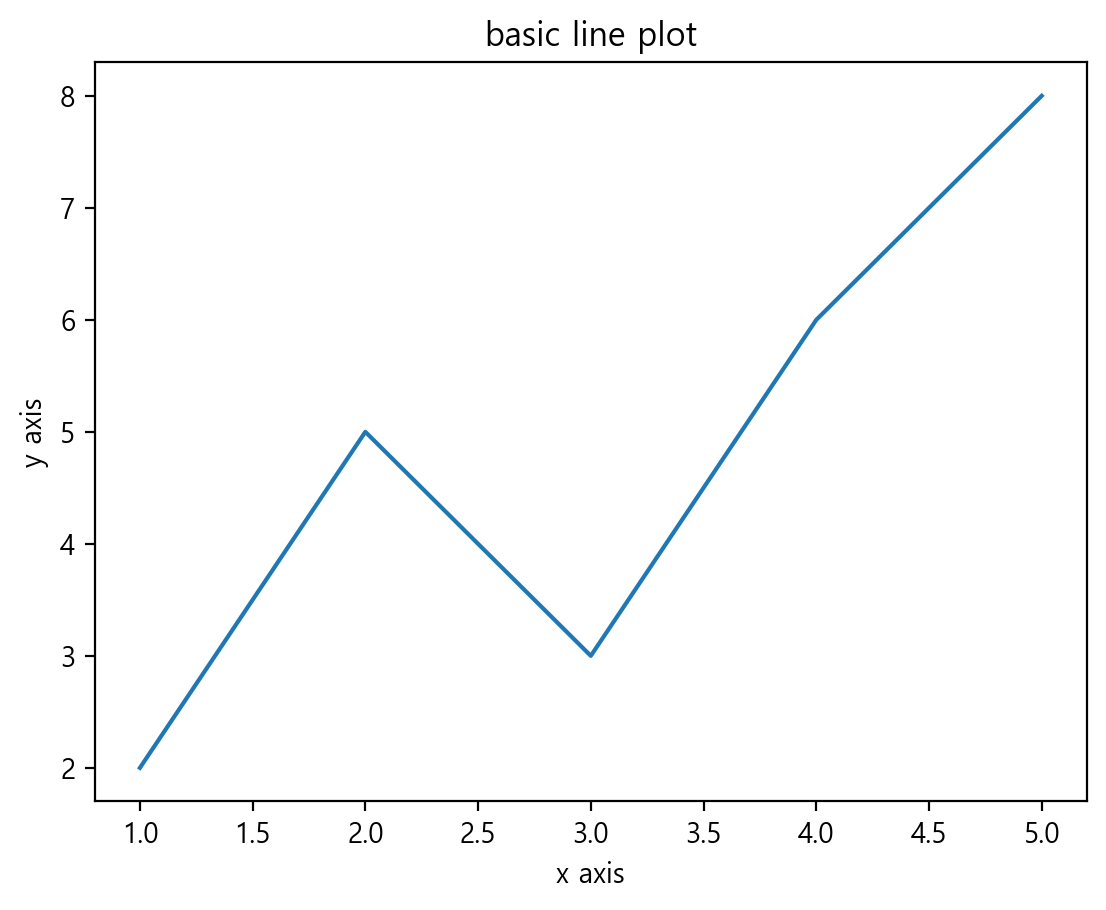

In [3]:
# basic line plot
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 5, 3, 6, 8])
plt.plot(x,y)
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.title('basic line plot')
plt.show()

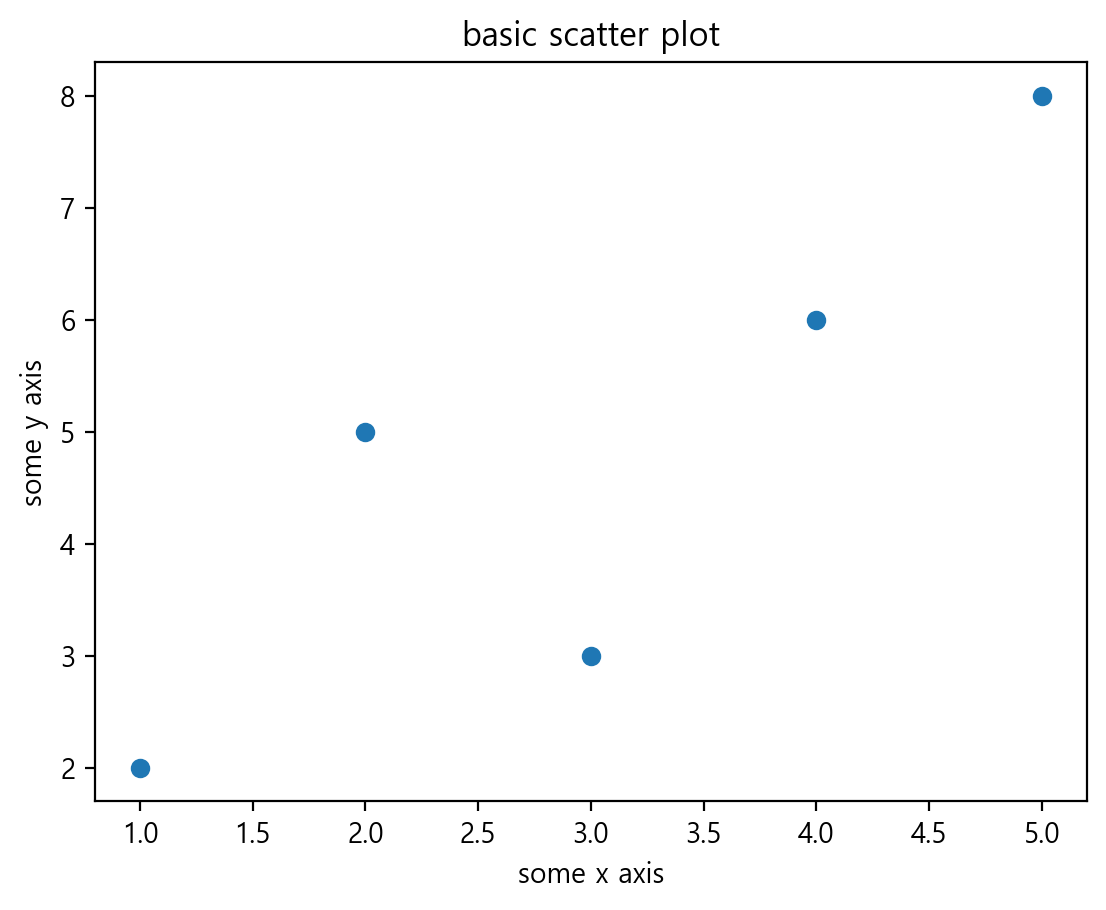

In [4]:
# basic scatter plot
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 5, 3, 6, 8])
plt.scatter(x,y)
plt.xlabel('some x axis')
plt.ylabel('some y axis')
plt.title('basic scatter plot')
plt.show()

## 1. Histogram
Purpose: Showing the distribution of a numerical variable

In [5]:
# Example data: Drinks data
drink_cols = ['country', 'beer', 'spirit', 'wine', 'pure', 'continent']
url = 'https://raw.githubusercontent.com/justmarkham/DAT8/master/data/drinks.csv'
drinks = pd.read_csv(url, header=0, names=drink_cols, na_filter=False)
drinks

,country,beer,spirit,wine,pure,continent
0,Afghanistan,0,0,0,0.0,AS
1,Albania,89,132,54,4.9,EU
2,Algeria,25,0,14,0.7,AF
3,Andorra,245,138,312,12.4,EU
4,Angola,217,57,45,5.9,AF
...,...,...,...,...,...,...
188,Venezuela,333,100,3,7.7,SA
189,Vietnam,111,2,1,2.0,AS
190,Yemen,6,0,0,0.1,AS
191,Zambia,32,19,4,2.5,AF


In [6]:
# sort the beer column 
drinks.beer.sort_values(ascending=True)

0        0
40       0
79       0
90       0
97       0
      ... 
135    343
65     346
62     347
45     361
117    376
Name: beer, Length: 193, dtype: int64

<AxesSubplot:ylabel='Frequency'>

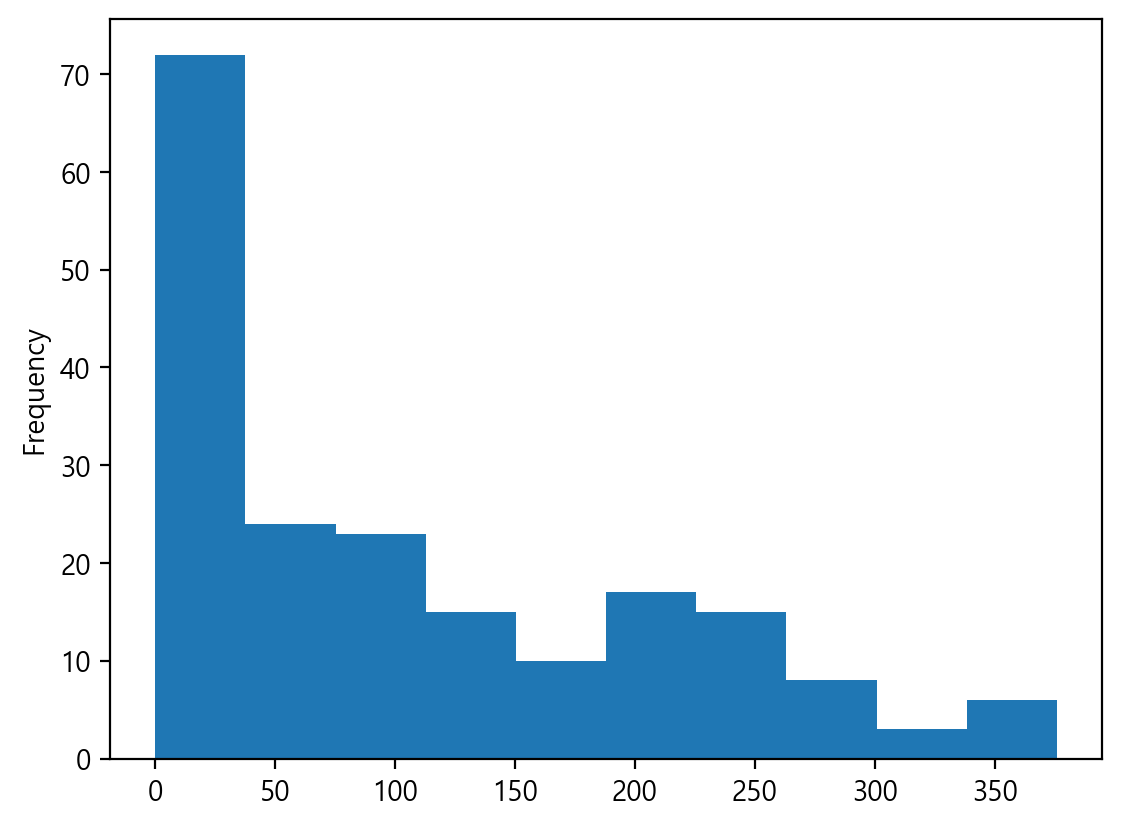

In [8]:
# compare with histogram
drinks.beer.plot(kind='hist', bins=10)

Text(0.5, 1.0, 'Histogram of Beer Servings')

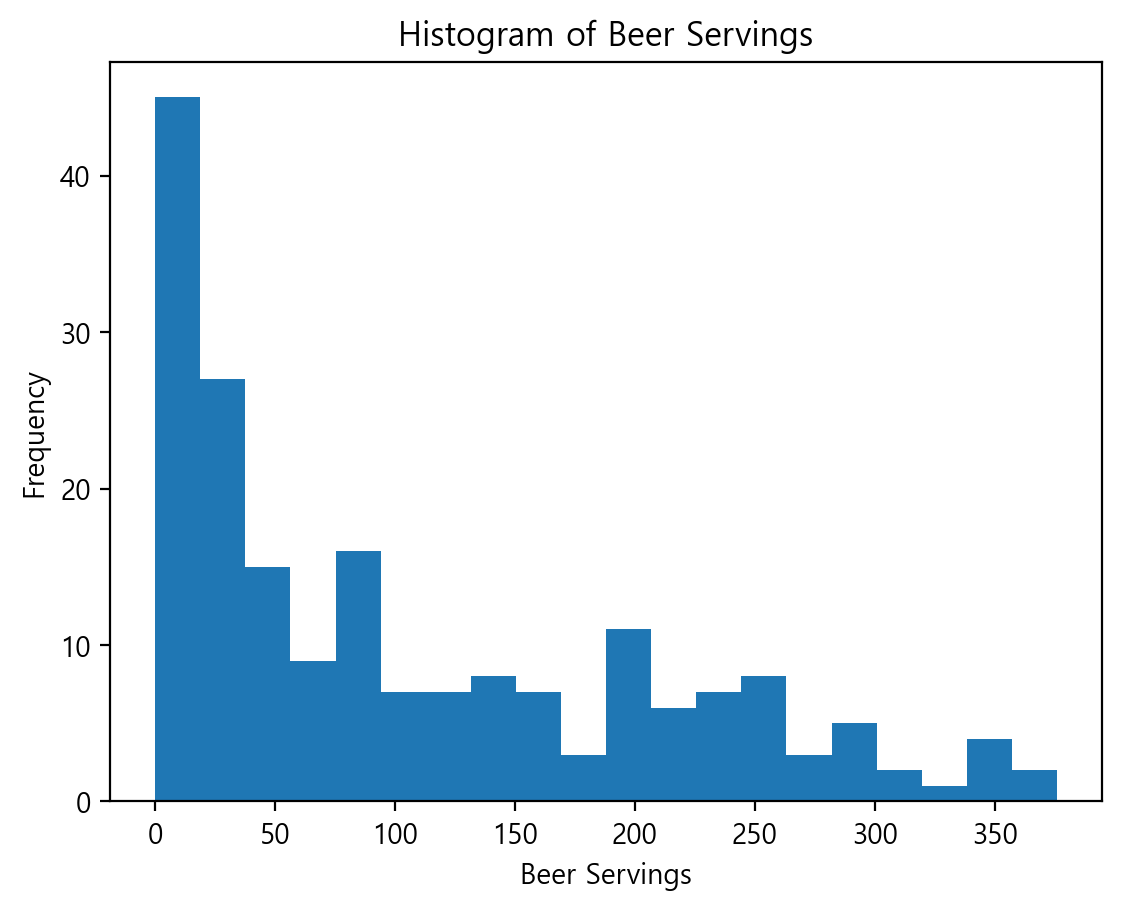

In [9]:
# try more bins
# add title and labels
drinks.beer.plot(kind='hist', bins=20)
plt.xlabel('Beer Servings')
plt.ylabel('Frequency')
plt.title('Histogram of Beer Servings')

<AxesSubplot:ylabel='Density'>

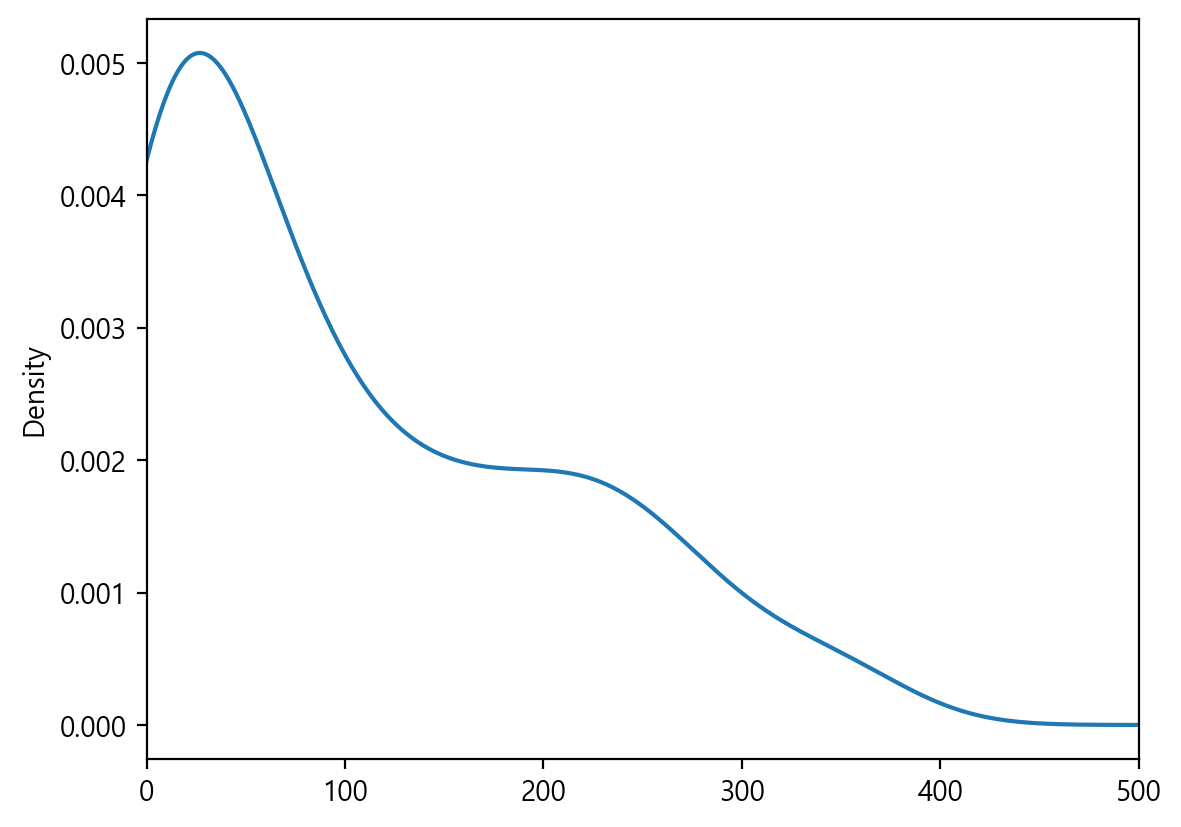

In [10]:
# compare with density plot (smooth version of a histogram)
drinks.beer.plot(kind='density', xlim=(0, 500))

array([[<AxesSubplot:title={'center':'beer'}>]], dtype=object)

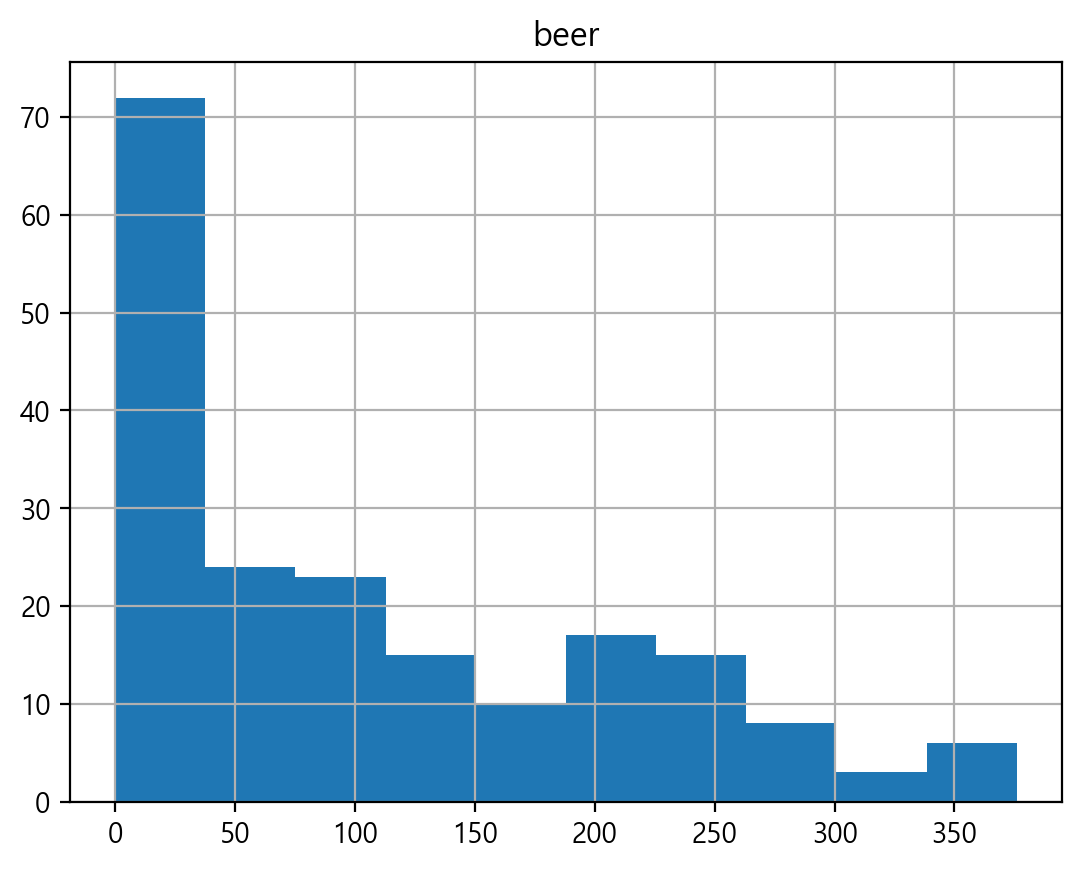

In [12]:
drinks.hist(column='beer')

array([[<AxesSubplot:title={'center':'AF'}>,
        <AxesSubplot:title={'center':'AS'}>],
       [<AxesSubplot:title={'center':'EU'}>,
        <AxesSubplot:title={'center':'NA'}>],
       [<AxesSubplot:title={'center':'OC'}>,
        <AxesSubplot:title={'center':'SA'}>]], dtype=object)

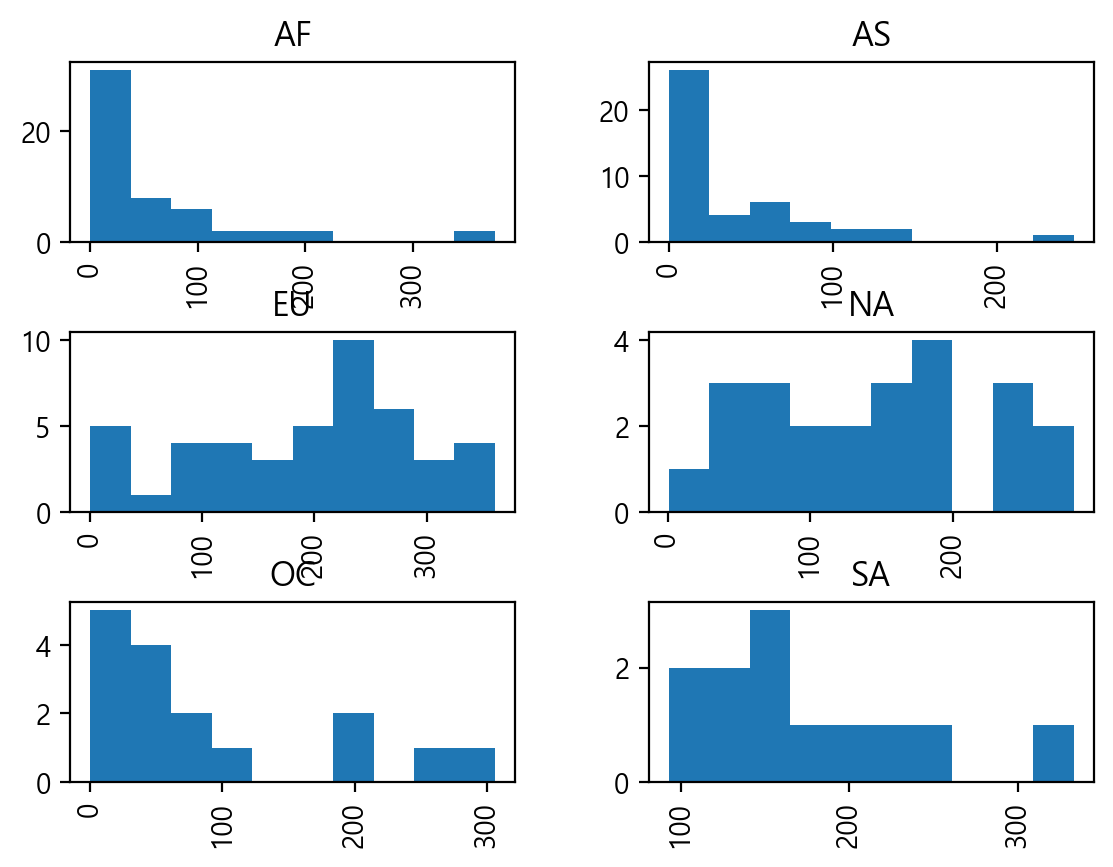

In [11]:
# histogram of beer servings grouped by continent
drinks.hist(column='beer', by='continent')

array([[<AxesSubplot:title={'center':'AF'}>,
        <AxesSubplot:title={'center':'AS'}>],
       [<AxesSubplot:title={'center':'EU'}>,
        <AxesSubplot:title={'center':'NA'}>],
       [<AxesSubplot:title={'center':'OC'}>,
        <AxesSubplot:title={'center':'SA'}>]], dtype=object)

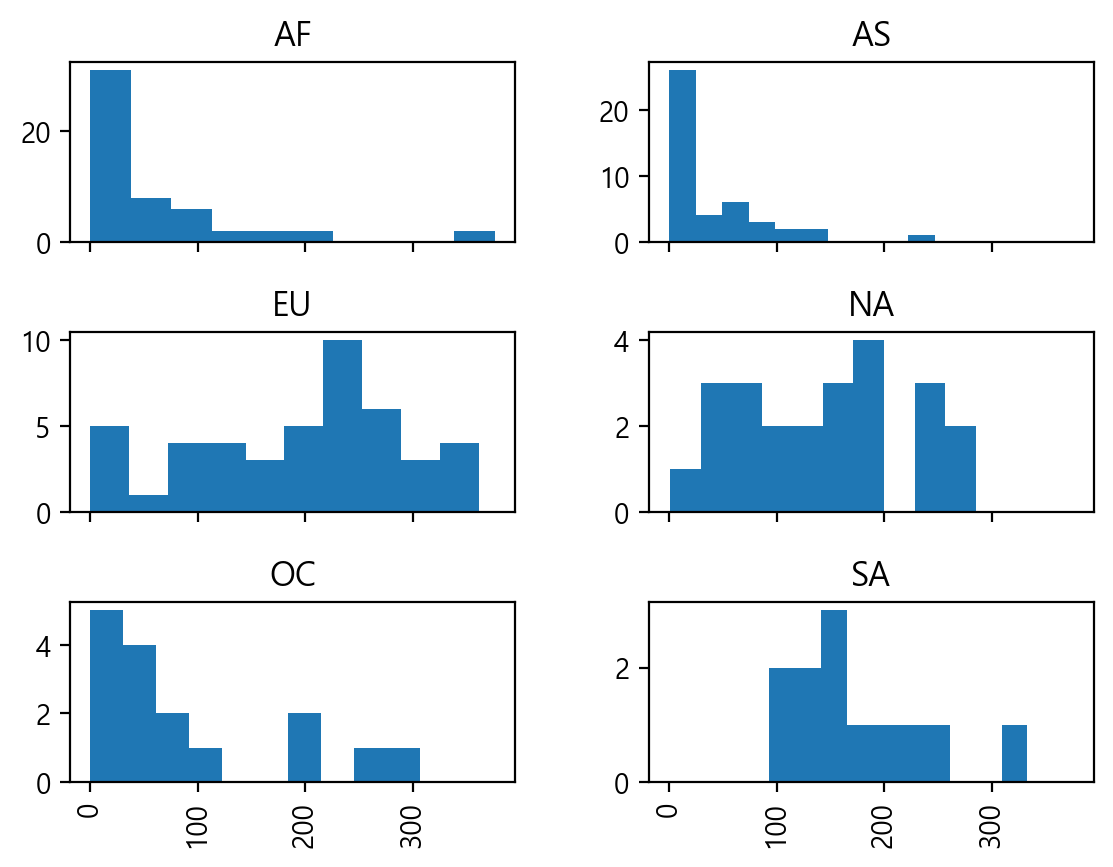

In [13]:
# share the x axes
drinks.hist(column='beer', by='continent', sharex=True)

array([[<AxesSubplot:title={'center':'AF'}>,
        <AxesSubplot:title={'center':'AS'}>],
       [<AxesSubplot:title={'center':'EU'}>,
        <AxesSubplot:title={'center':'NA'}>],
       [<AxesSubplot:title={'center':'OC'}>,
        <AxesSubplot:title={'center':'SA'}>]], dtype=object)

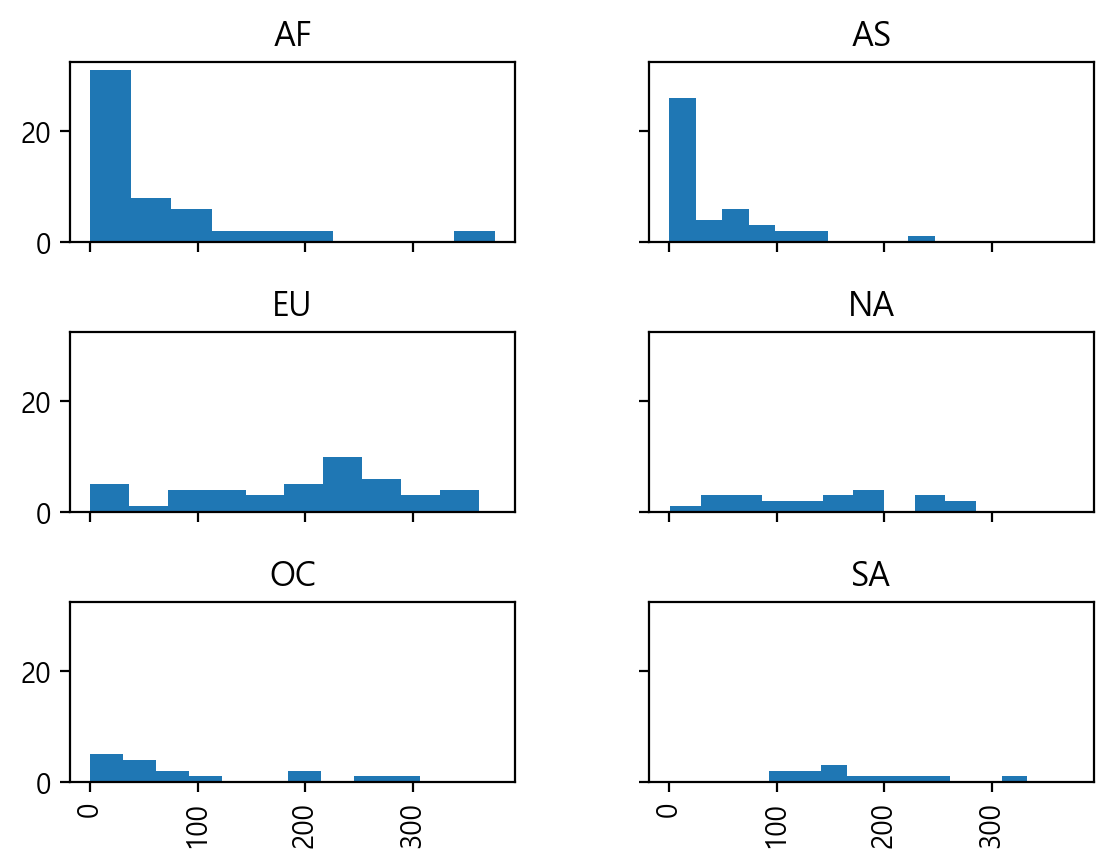

In [14]:
# share the x and y axes
drinks.hist(column='beer', by='continent', sharex=True, sharey=True)

array([[<AxesSubplot:title={'center':'AF'}>,
        <AxesSubplot:title={'center':'AS'}>,
        <AxesSubplot:title={'center':'EU'}>],
       [<AxesSubplot:title={'center':'NA'}>,
        <AxesSubplot:title={'center':'OC'}>,
        <AxesSubplot:title={'center':'SA'}>]], dtype=object)

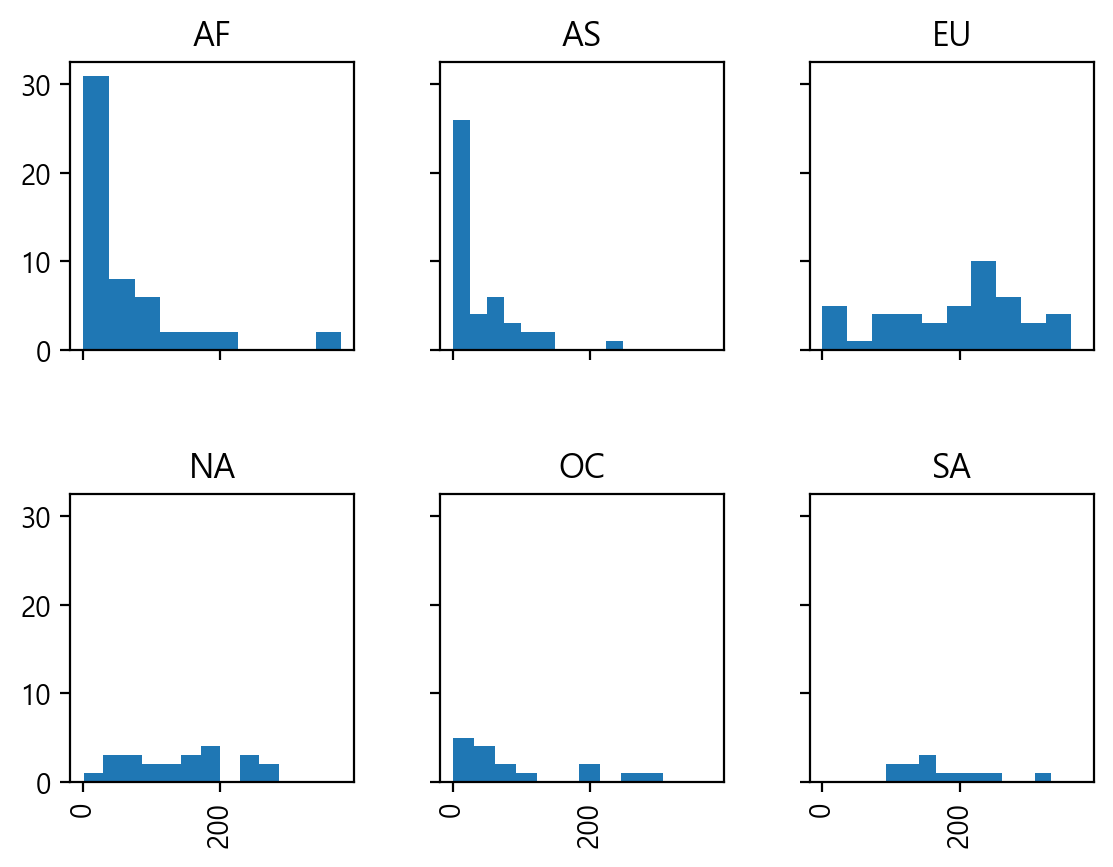

In [16]:
# change the layout
drinks.hist(column='beer', by='continent', sharex=True, sharey=True, layout=(2, 3))

## 2. Scatter plot
Purpose: Showing the relationship between two numerical variables

In [16]:
# select the beer and wine columns and sort by beer
drinks[['beer', 'wine']].sort_values(by='beer')

,beer,wine
0,0,0
40,0,74
79,0,0
90,0,0
97,0,0
...,...,...
135,343,56
65,346,175
62,347,59
45,361,134


<AxesSubplot:xlabel='beer', ylabel='wine'>

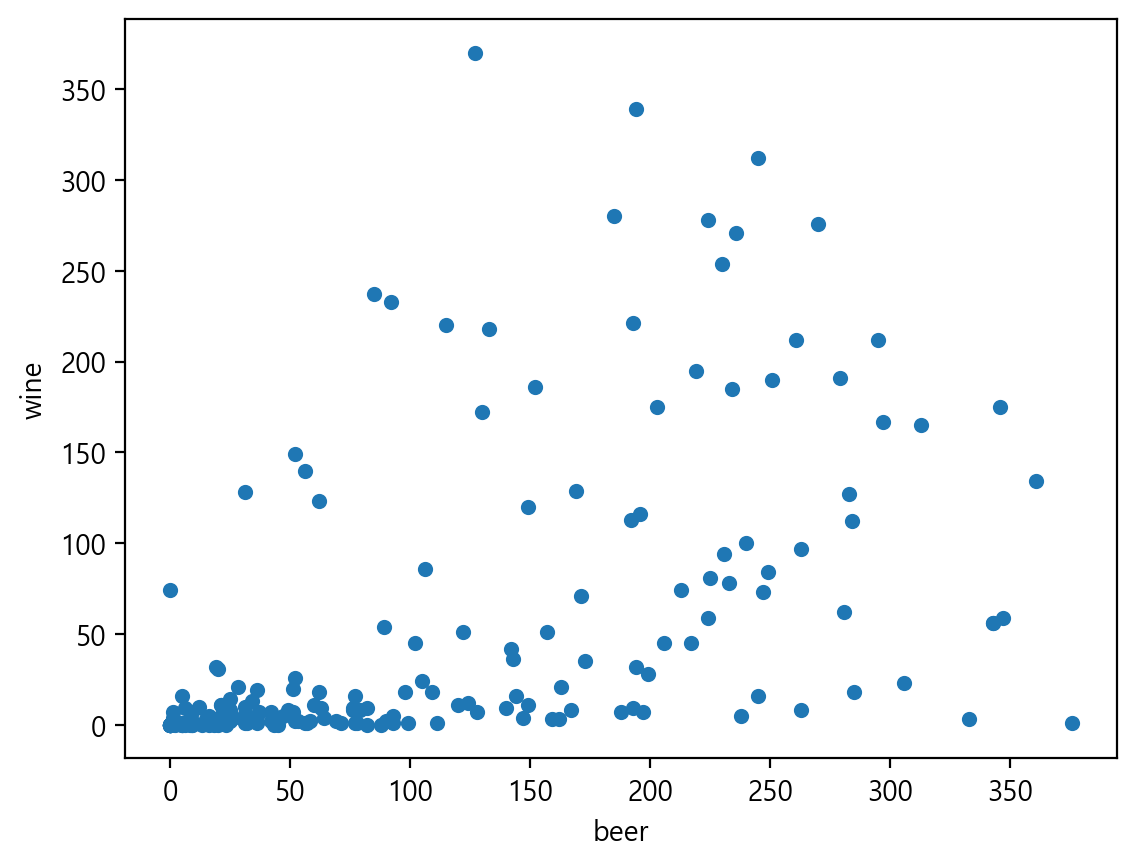

In [17]:
# compare with scatter plot
drinks.plot(kind='scatter', x='beer', y='wine')

<AxesSubplot:xlabel='beer', ylabel='wine'>

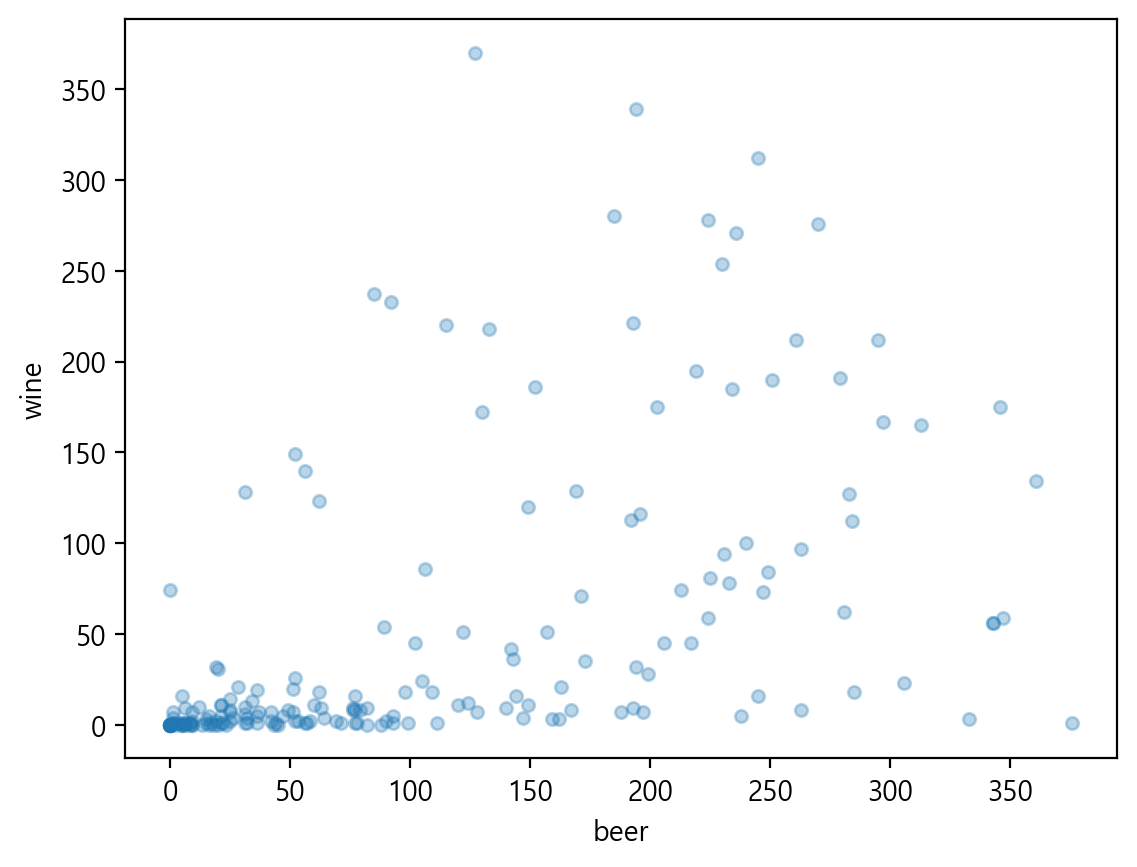

In [18]:
# add transparency
drinks.plot(kind='scatter', x='beer', y='wine', alpha=0.3)

<AxesSubplot:xlabel='beer', ylabel='wine'>

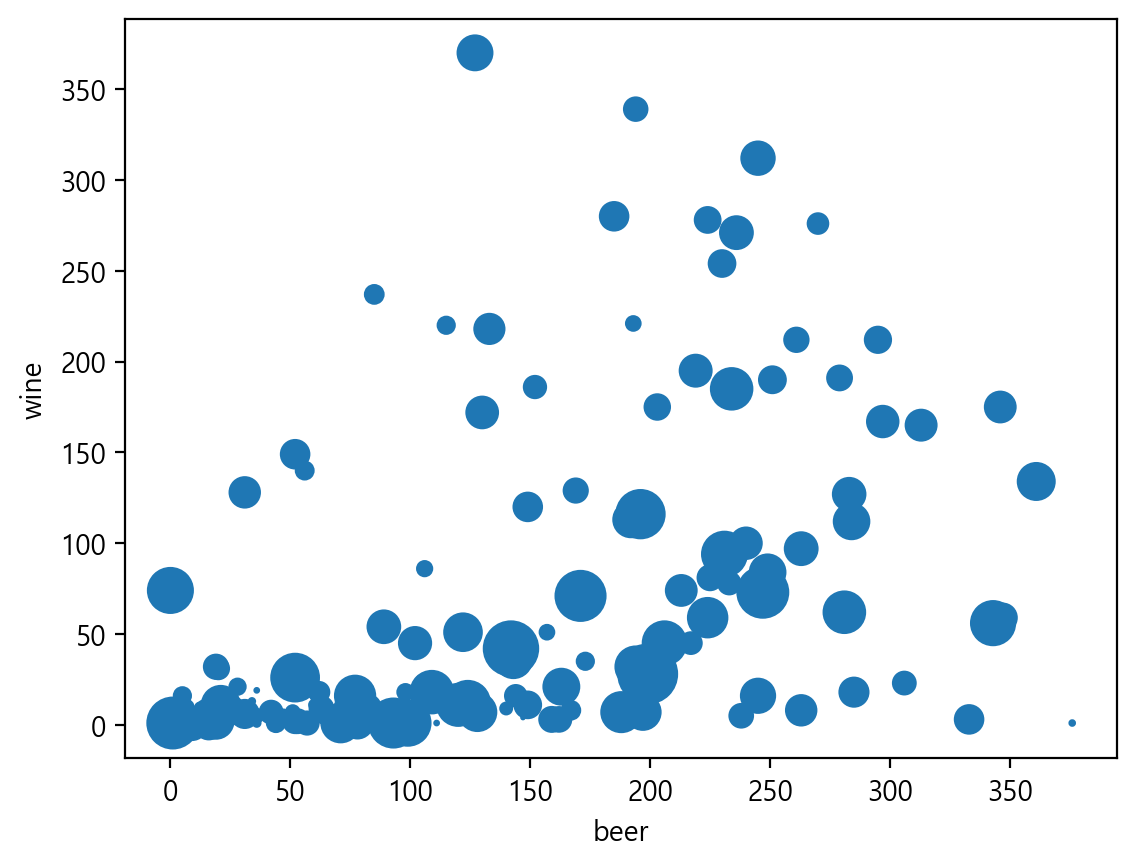

In [19]:
# vary point size by spirit servings
drinks.plot(kind='scatter', x='beer', y='wine', s='spirit')

## Matplotlib Color Maps
https://matplotlib.org/stable/tutorials/colors/colormaps.html

<AxesSubplot:xlabel='beer', ylabel='wine'>

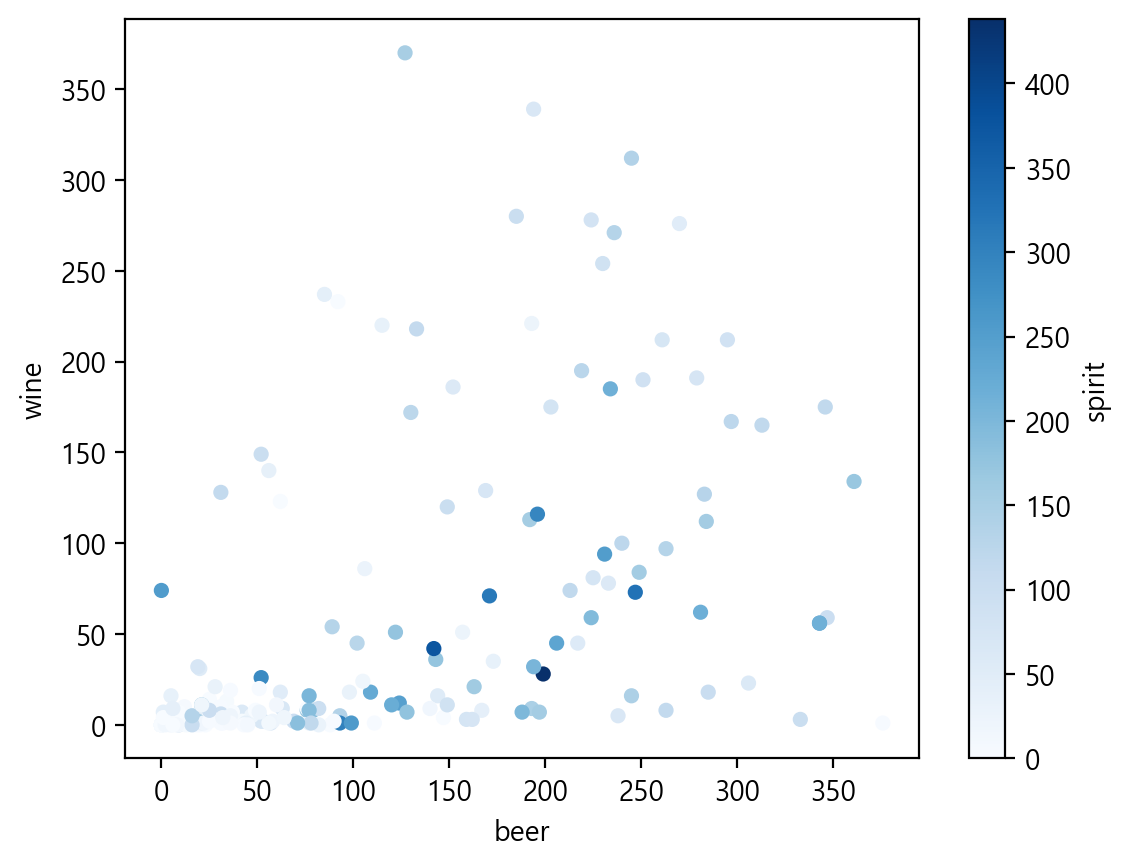

In [21]:
# vary point color by spirit servings
drinks.plot(kind='scatter', x='beer', y='wine', c='spirit', colormap='Blues')

<AxesSubplot:xlabel='beer', ylabel='wine'>

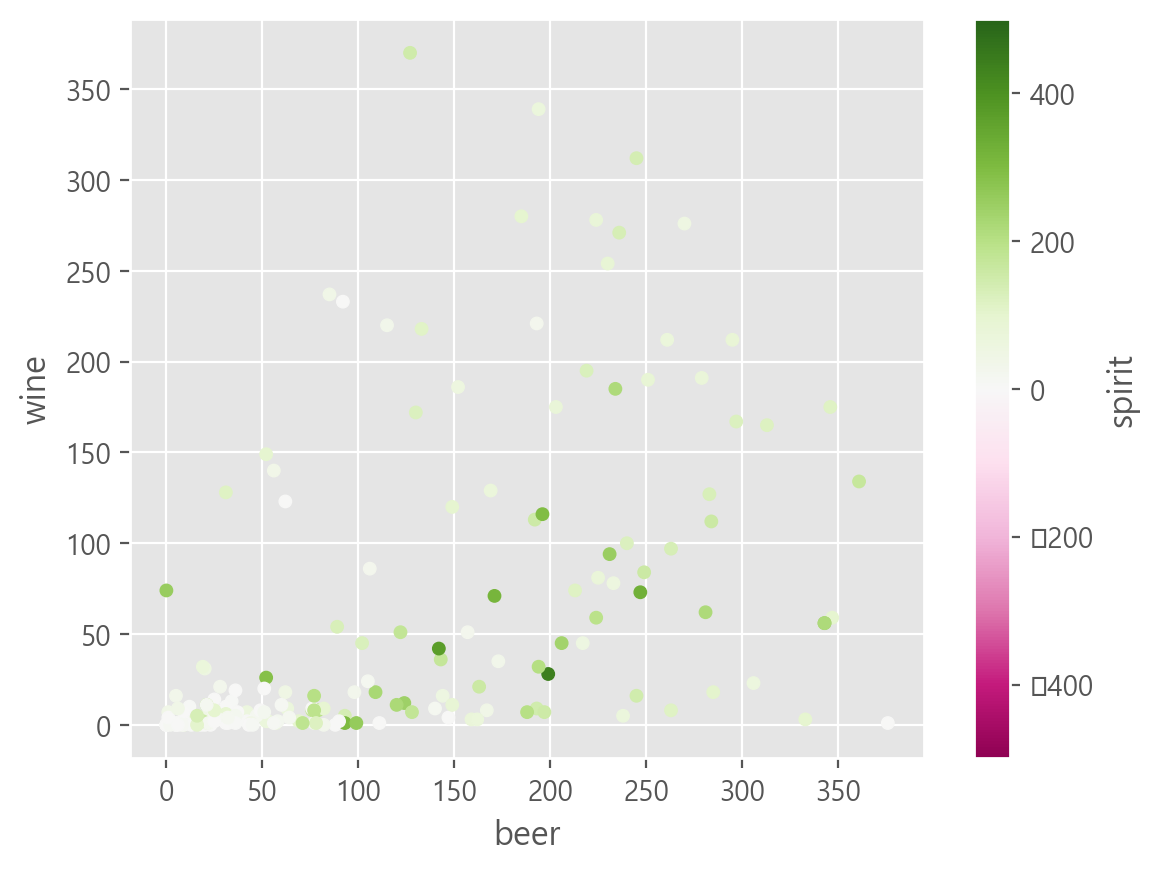

In [49]:
drinks.plot(kind='scatter', x='beer', y='wine', c='spirit', colormap='PiYG', vmin=-500, vmax=500)

array([[<AxesSubplot:xlabel='beer', ylabel='beer'>,
        <AxesSubplot:xlabel='spirit', ylabel='beer'>,
        <AxesSubplot:xlabel='wine', ylabel='beer'>],
       [<AxesSubplot:xlabel='beer', ylabel='spirit'>,
        <AxesSubplot:xlabel='spirit', ylabel='spirit'>,
        <AxesSubplot:xlabel='wine', ylabel='spirit'>],
       [<AxesSubplot:xlabel='beer', ylabel='wine'>,
        <AxesSubplot:xlabel='spirit', ylabel='wine'>,
        <AxesSubplot:xlabel='wine', ylabel='wine'>]], dtype=object)

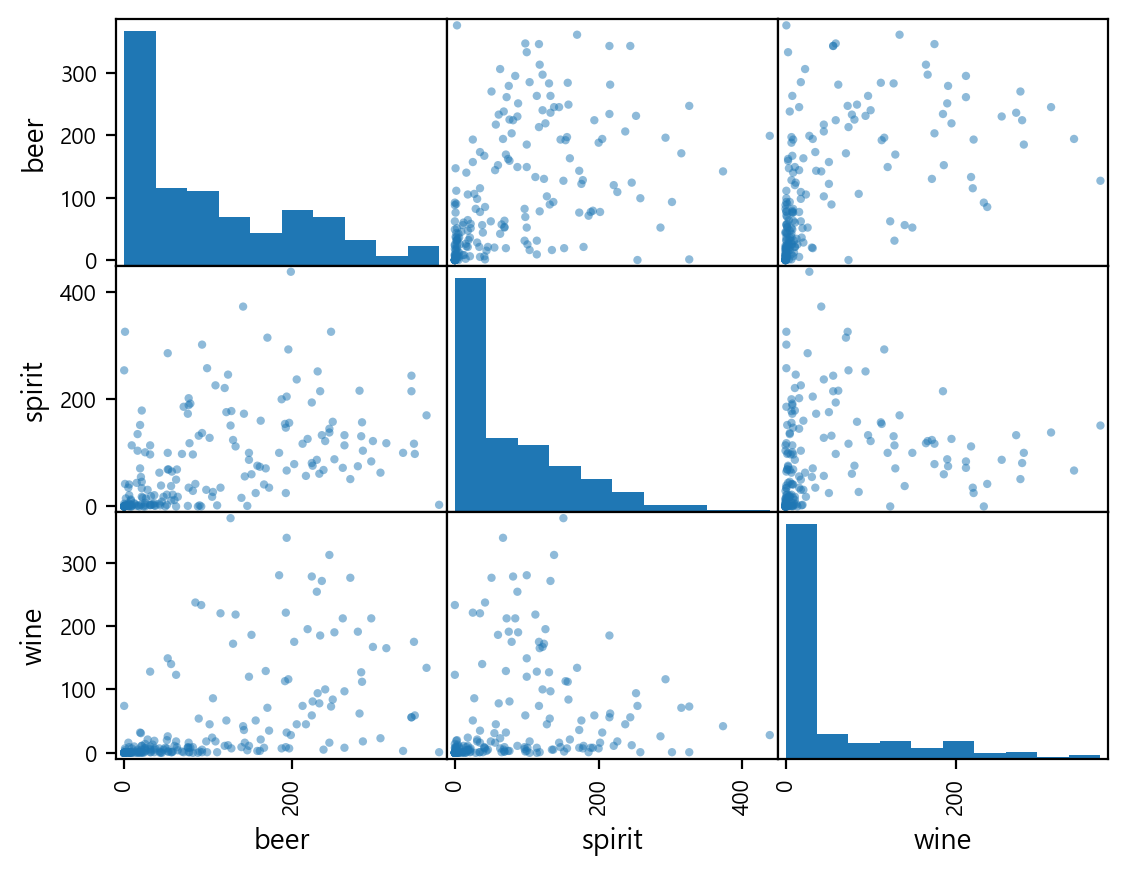

In [22]:
# scatter matrix of three numerical columns
pd.plotting.scatter_matrix(drinks[['beer', 'spirit', 'wine']])

array([[<AxesSubplot:xlabel='beer', ylabel='beer'>,
        <AxesSubplot:xlabel='spirit', ylabel='beer'>,
        <AxesSubplot:xlabel='wine', ylabel='beer'>],
       [<AxesSubplot:xlabel='beer', ylabel='spirit'>,
        <AxesSubplot:xlabel='spirit', ylabel='spirit'>,
        <AxesSubplot:xlabel='wine', ylabel='spirit'>],
       [<AxesSubplot:xlabel='beer', ylabel='wine'>,
        <AxesSubplot:xlabel='spirit', ylabel='wine'>,
        <AxesSubplot:xlabel='wine', ylabel='wine'>]], dtype=object)

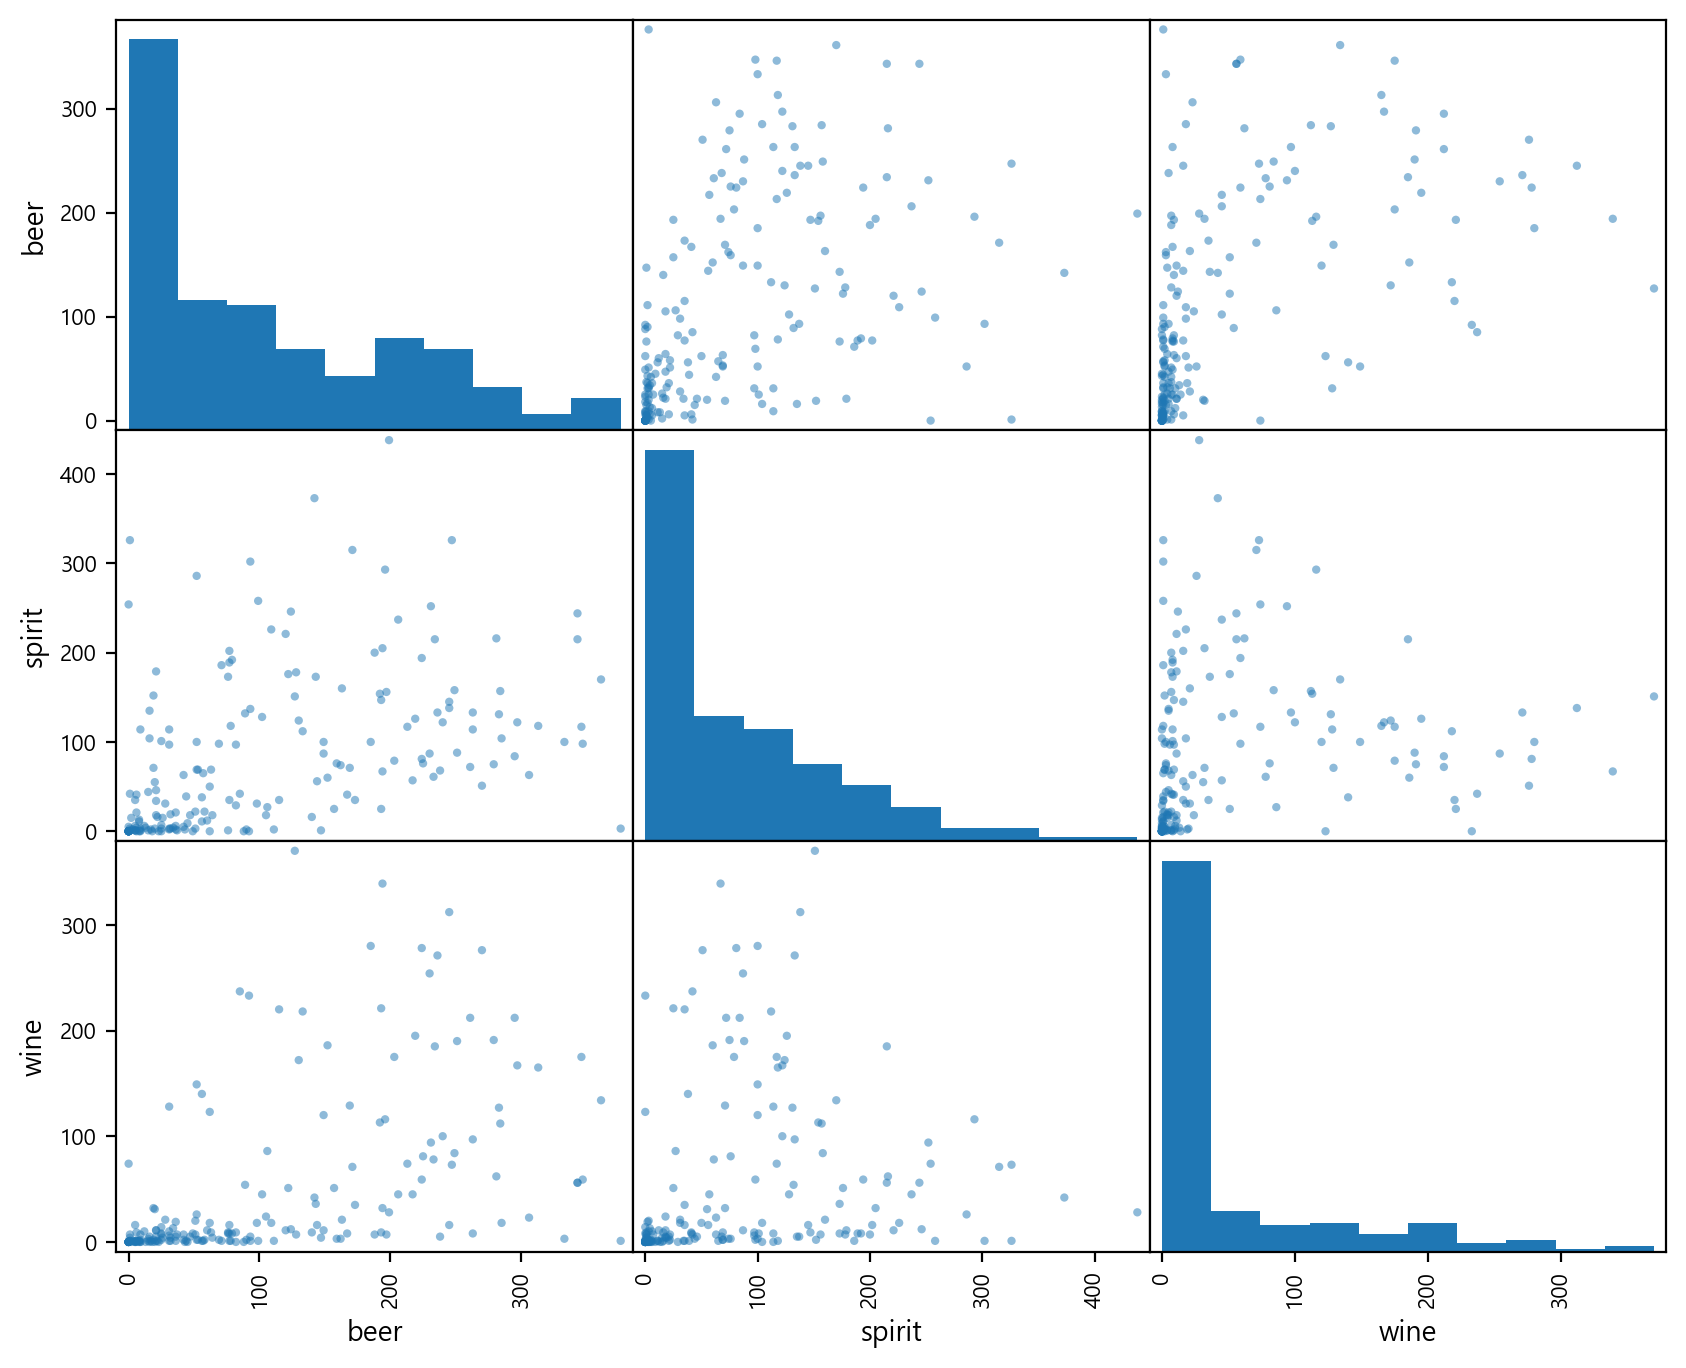

In [23]:
# increase figure size
pd.plotting.scatter_matrix(drinks[['beer', 'spirit', 'wine']], figsize=(10, 8))

## 3. Bar plot
Purpose: Showing a numerical comparison across different categories

In [24]:
# count the number of countries in each continent
drinks.continent.value_counts()

AF    53
EU    45
AS    44
NA    23
OC    16
SA    12
Name: continent, dtype: int64

<AxesSubplot:>

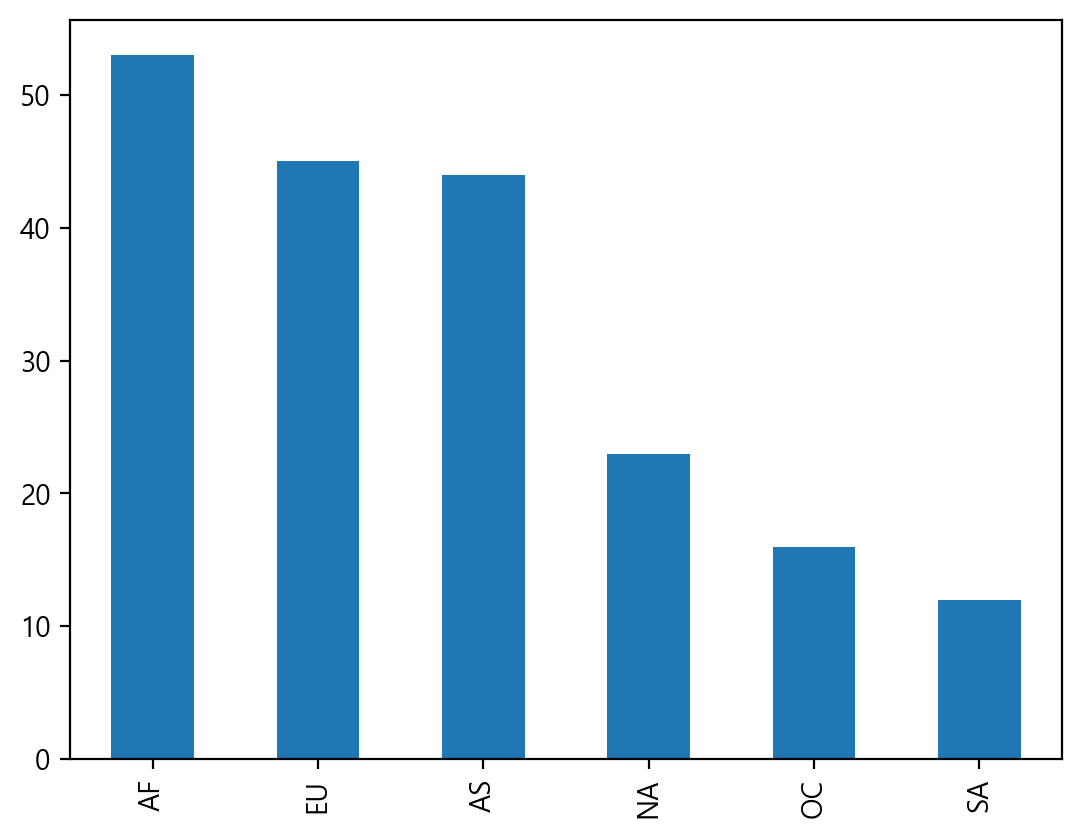

In [25]:
# compare with bar plot
drinks.continent.value_counts().plot(kind='bar')

In [26]:
# calculate the mean alcohol amounts for each continent
drink_continent=drinks.groupby(['continent'])[['beer','spirit','wine','pure']].agg(['mean']).droplevel(axis=1,level=1).reset_index()
drink_continent

,continent,beer,spirit,wine,pure
0,AF,61.5,16.3,16.3,3.0
1,AS,37.0,60.8,9.1,2.2
2,EU,193.8,132.6,142.2,8.6
3,NA,145.4,165.7,24.5,6.0
4,OC,89.7,58.4,35.6,3.4
5,SA,175.1,114.8,62.4,6.3


<AxesSubplot:>

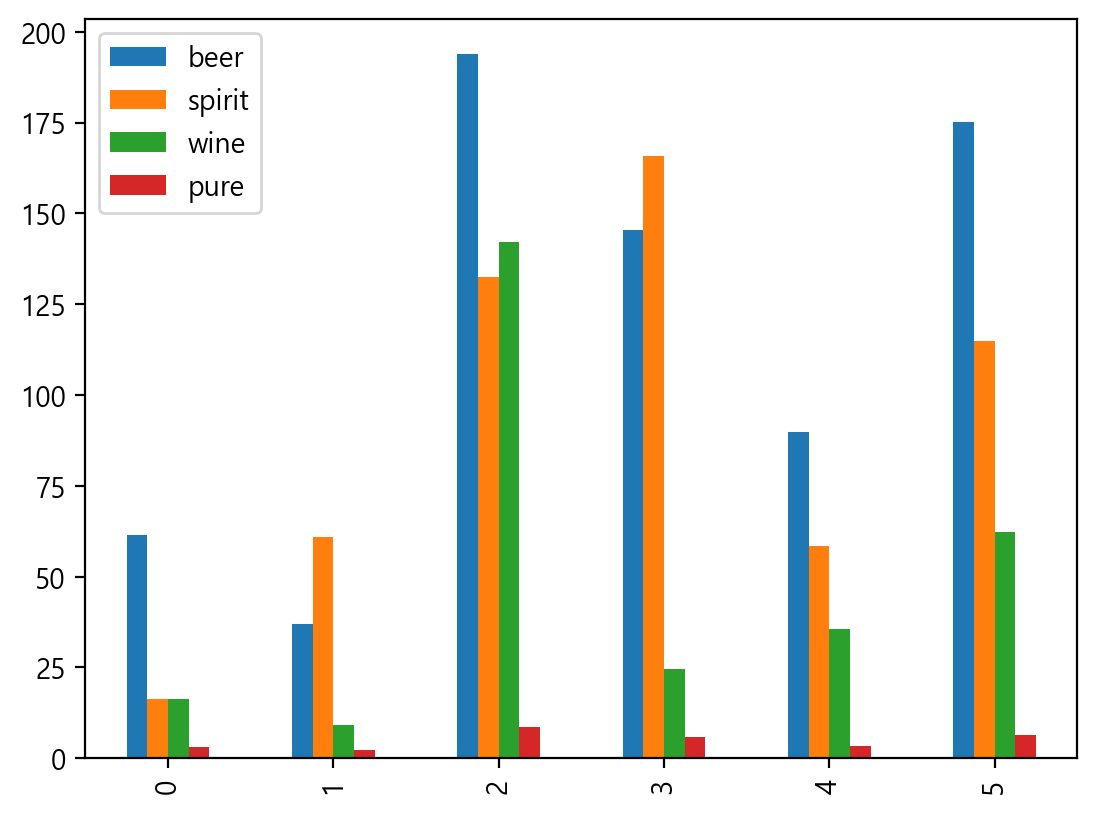

In [27]:
# side-by-side bar plots
drink_continent.plot(kind='bar')

<AxesSubplot:>

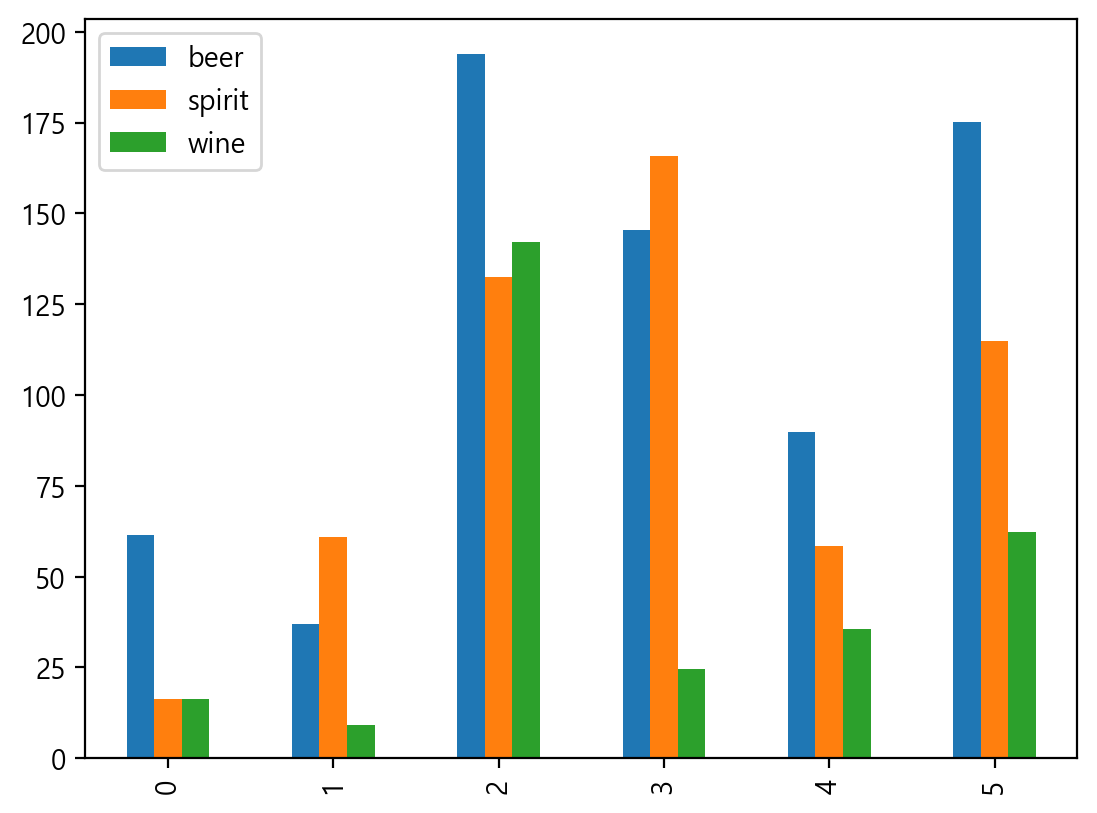

In [28]:
# drop the liters column
drink_continent.drop('pure', axis=1).plot(kind='bar')

<AxesSubplot:>

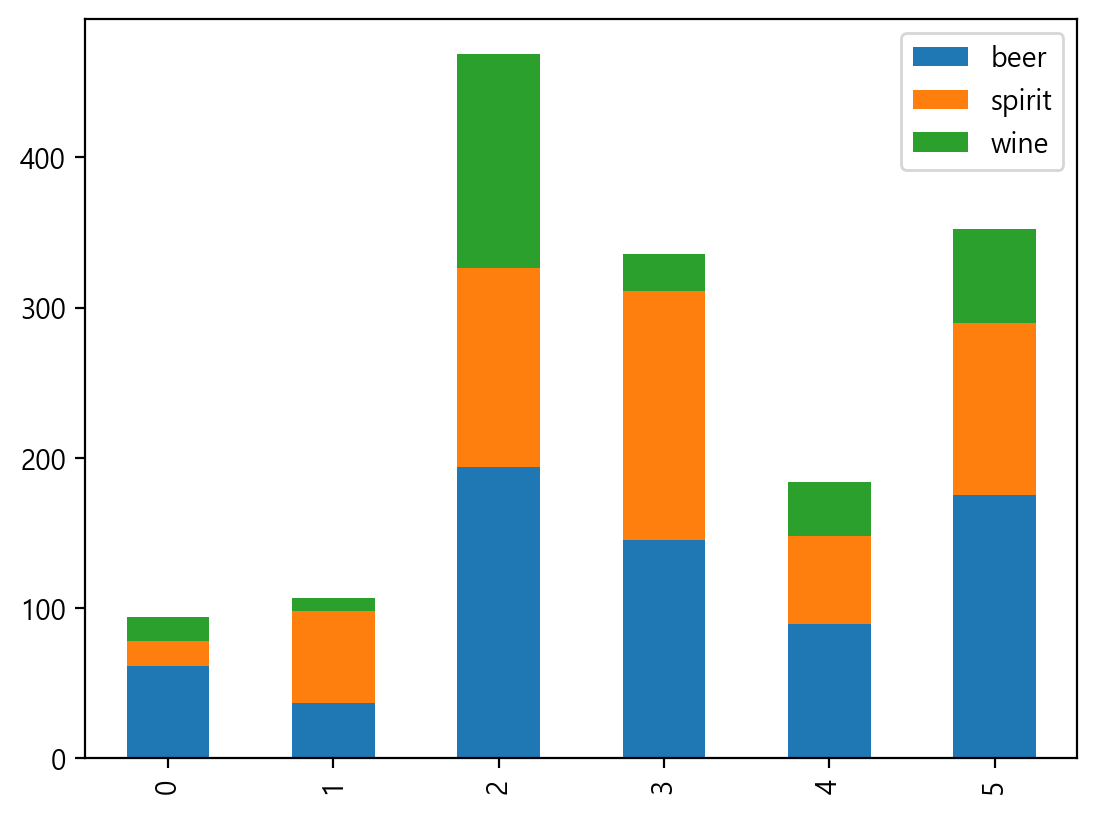

In [29]:
# stacked bar plots
drink_continent.drop('pure', axis=1).plot(kind='bar', stacked=True)

## 4. Box plot
Purpose: Showing quartiles and outliers for one or more numerical variables

**Five-number summary:**

- min = minimum value
- 25% = first quartile (Q1) = median of the lower half of the data
- 50% = second quartile (Q2) = median of the data
- 75% = third quartile (Q3) = median of the upper half of the data
- max = maximum value

(More useful than mean and standard deviation for describing skewed distributions)

**Interquartile Range (IQR)** = Q3 - Q1

**Outliers:**

- below Q1 - 1.5 * IQR
- above Q3 + 1.5 * IQR

In [30]:
# sort the spirit column
drinks.spirit.sort_values(ascending=True)

0        0
27       0
128      0
118      0
111      0
      ... 
144    315
73     326
141    326
15     373
68     438
Name: spirit, Length: 193, dtype: int64

In [41]:
# show "five-number summary" for spirit
drinks.spirit.describe()

count                  193.0
mean                    81.0
std                     88.3
min                      0.0
25%                      4.0
50%                     56.0
75%                    128.0
max                    438.0
Name: spirit, dtype: float64

<AxesSubplot:>

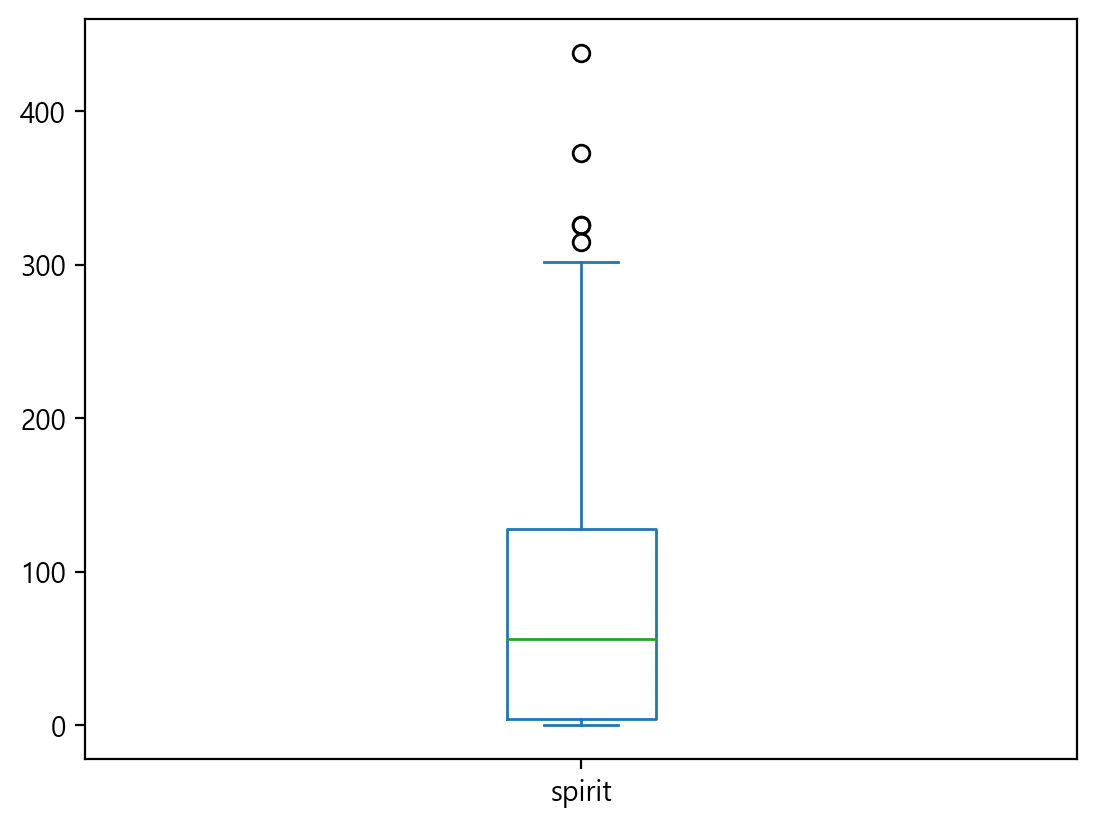

In [31]:
# compare with box plot
drinks.spirit.plot(kind='box')

<AxesSubplot:>

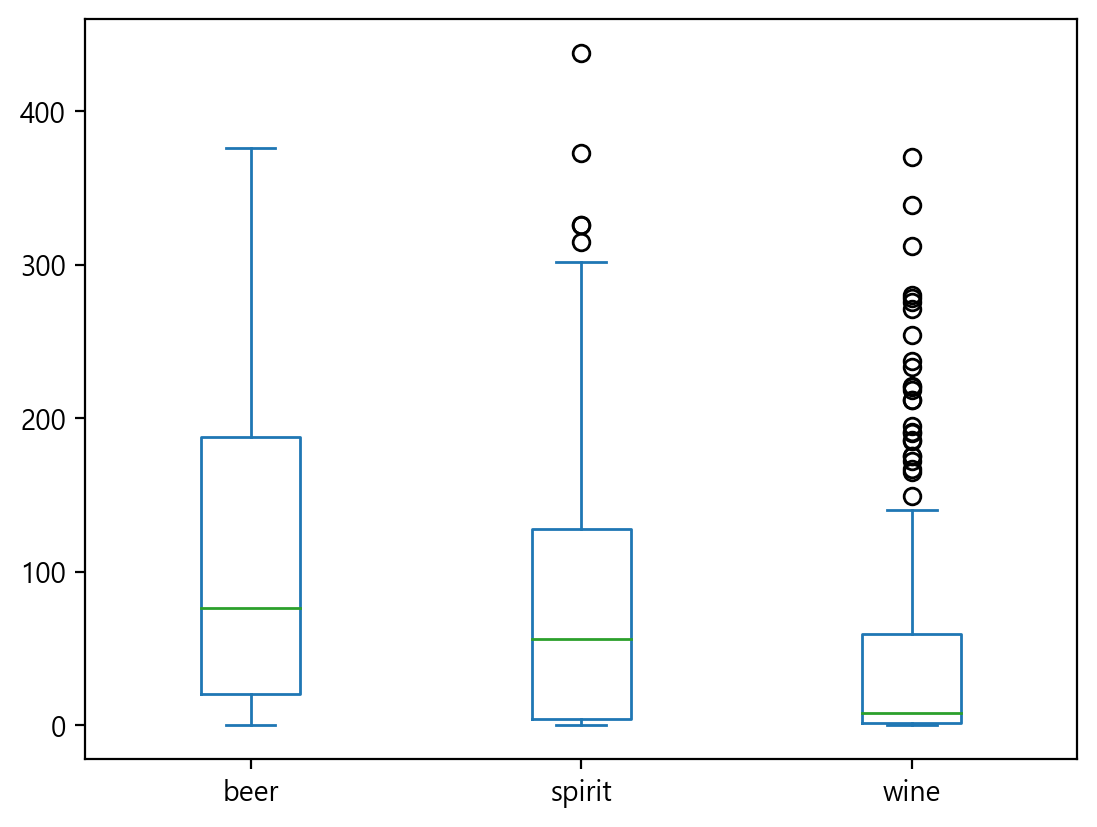

In [32]:
# include multiple variables
drinks.drop('pure', axis=1).plot(kind='box')

<AxesSubplot:title={'center':'beer'}, xlabel='continent'>

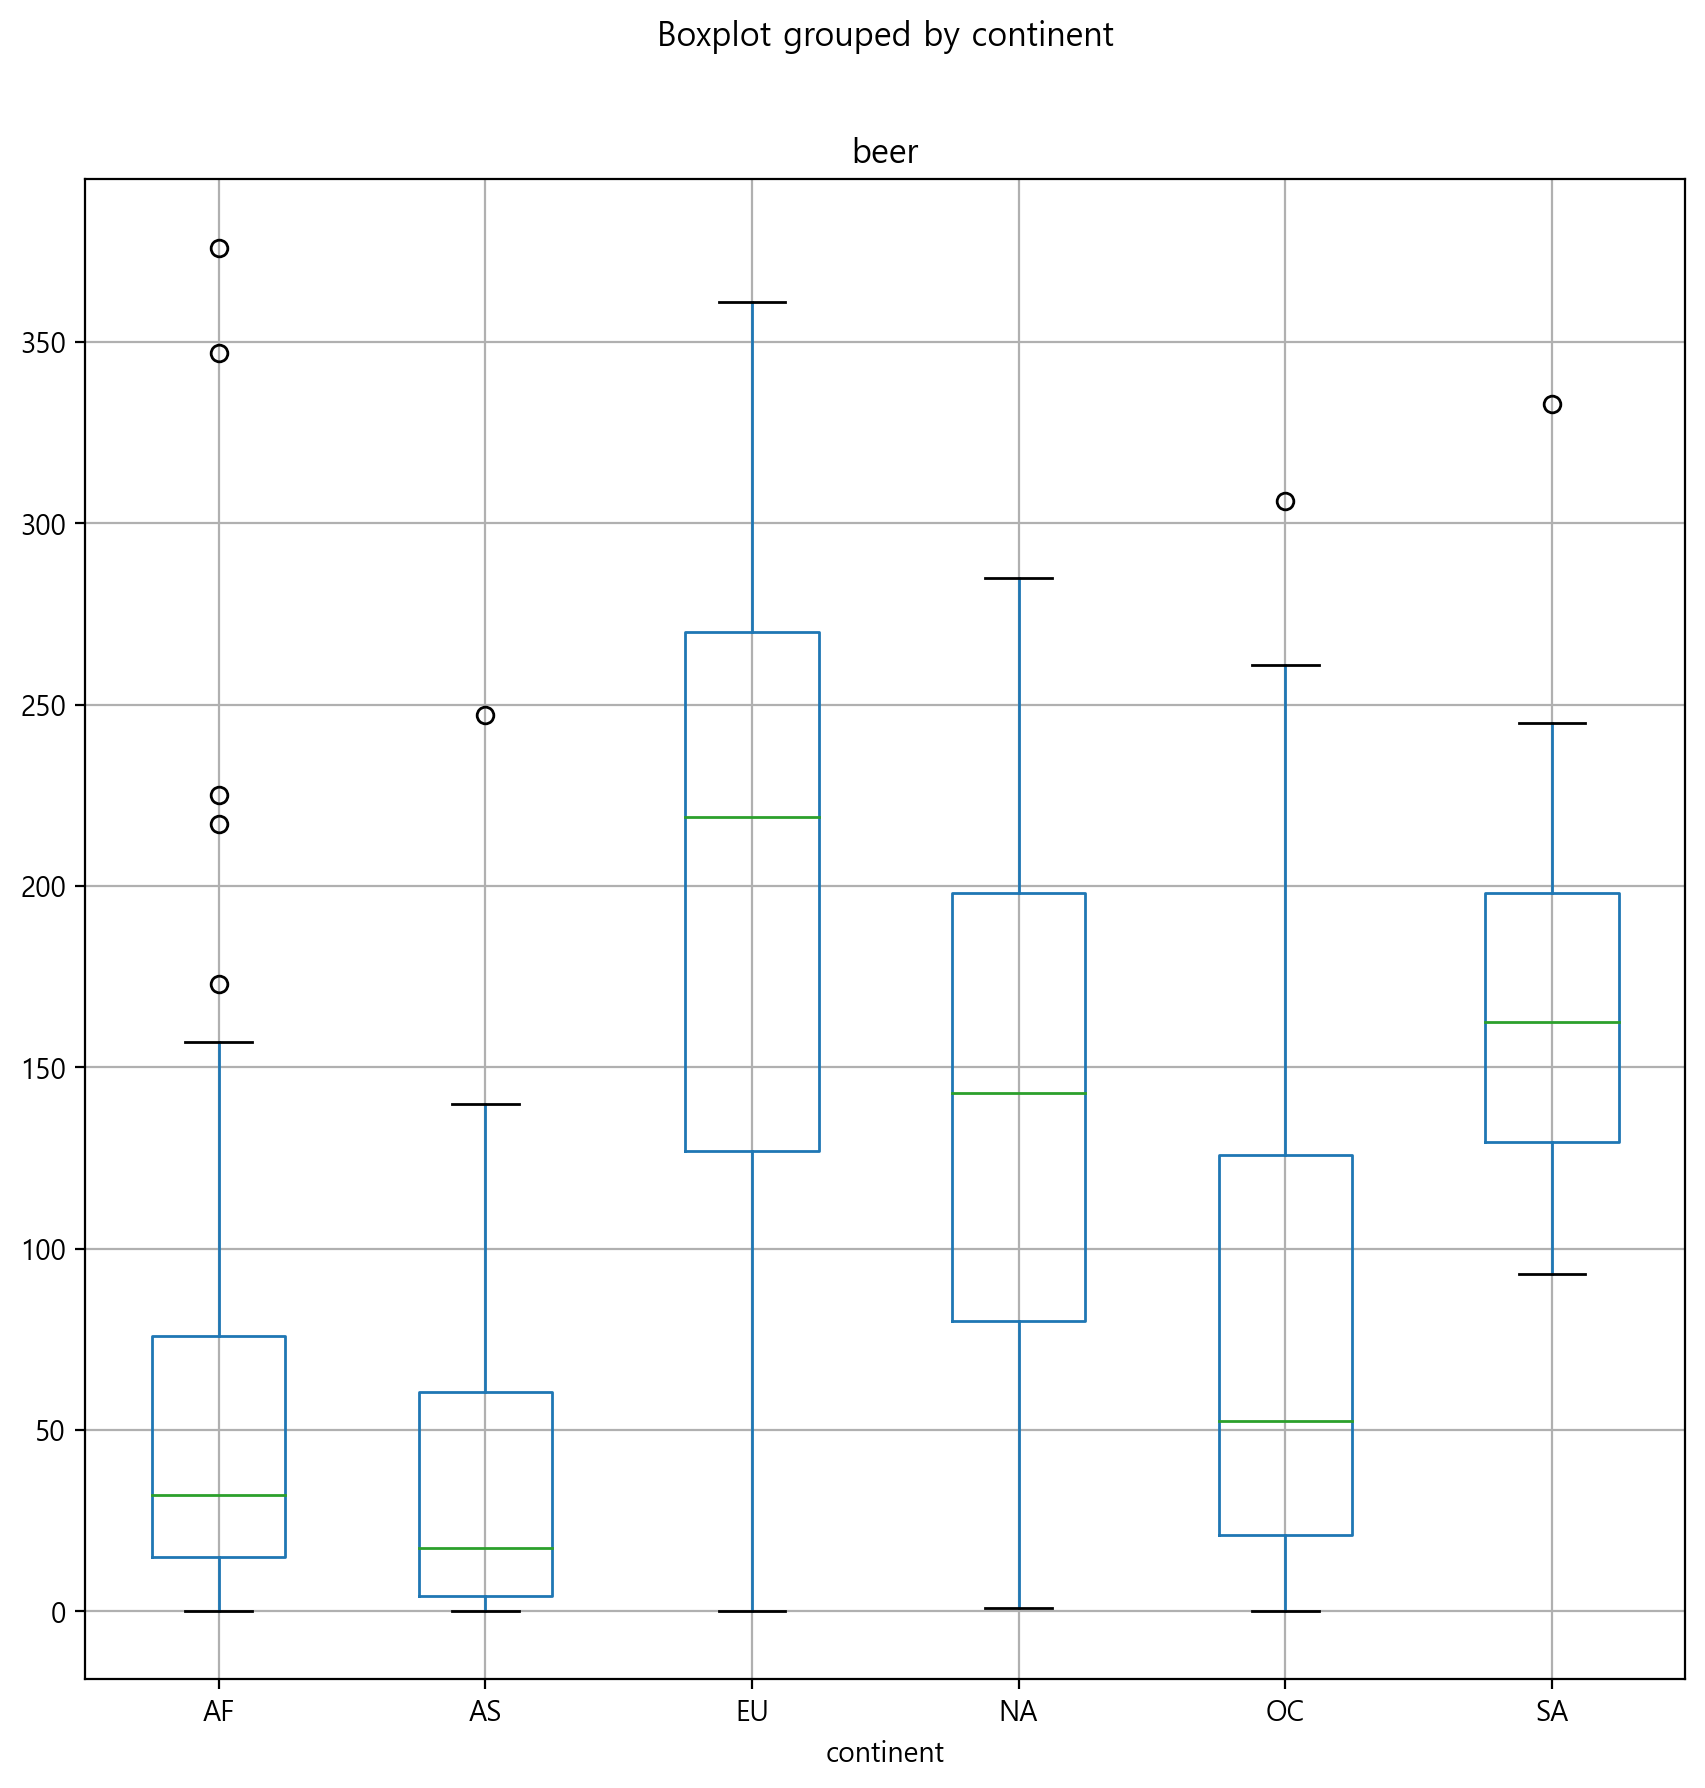

In [33]:
# box plot of beer servings grouped by continent
drinks.boxplot(column='beer', by='continent', figsize=(10, 10))

array([[<AxesSubplot:title={'center':'beer'}, xlabel='[continent]'>,
        <AxesSubplot:title={'center':'pure'}, xlabel='[continent]'>],
       [<AxesSubplot:title={'center':'spirit'}, xlabel='[continent]'>,
        <AxesSubplot:title={'center':'wine'}, xlabel='[continent]'>]],
      dtype=object)

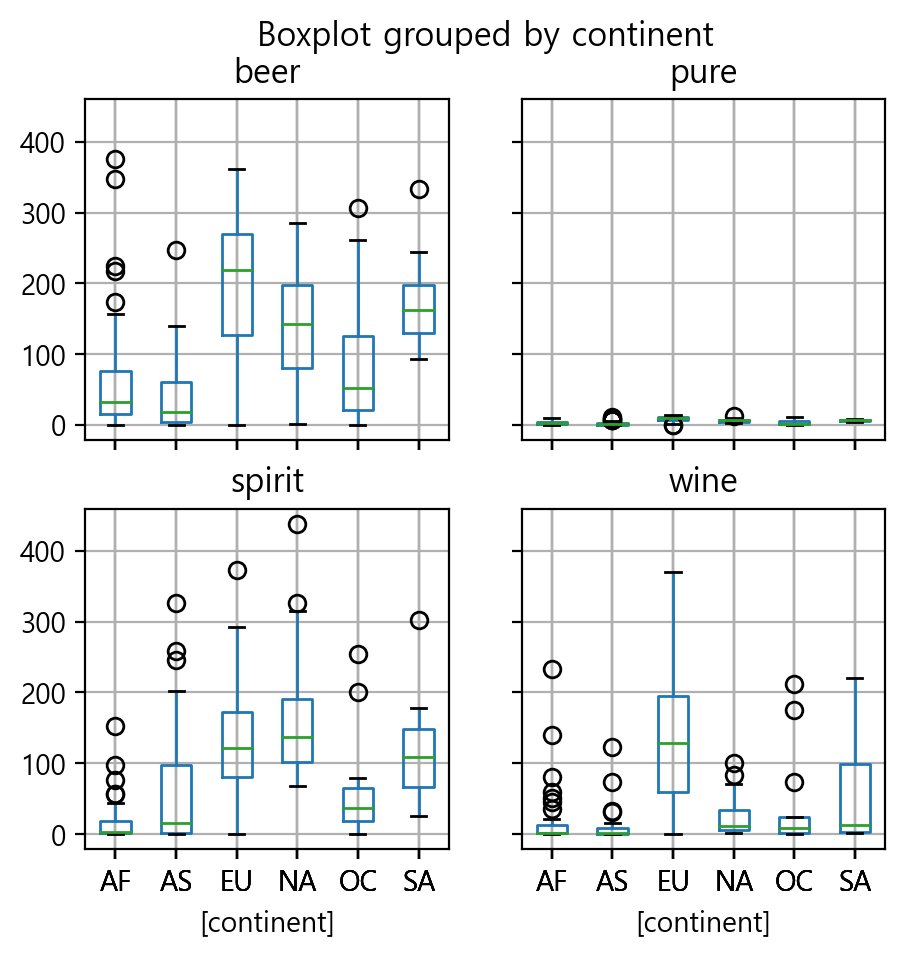

In [34]:
# box plot of all numeric columns grouped by continent
drinks.boxplot(by='continent', figsize=(5, 5))

## 5. Line plot
Purpose: Showing the trend of a numerical variable over time

In [35]:
# read in the ufo data
url = 'https://raw.githubusercontent.com/justmarkham/DAT8/master/data/ufo.csv'
ufo = pd.read_csv(url)
ufo['Time'] = pd.to_datetime(ufo.Time)
ufo['Year'] = ufo.Time.dt.year
ufo

,City,Colors Reported,Shape Reported,State,Time,Year
0,Ithaca,NaN,TRIANGLE,NY,1930-06-01 22:00:00,1930
1,Willingboro,NaN,OTHER,NJ,1930-06-30 20:00:00,1930
2,Holyoke,NaN,OVAL,CO,1931-02-15 14:00:00,1931
3,Abilene,NaN,DISK,KS,1931-06-01 13:00:00,1931
4,New York Worlds Fair,NaN,LIGHT,NY,1933-04-18 19:00:00,1933
...,...,...,...,...,...,...
80538,Neligh,NaN,CIRCLE,NE,2014-09-04 23:20:00,2014
80539,Uhrichsville,NaN,LIGHT,OH,2014-09-05 01:14:00,2014
80540,Tucson,RED BLUE,NaN,AZ,2014-09-05 02:40:00,2014
80541,Orland park,RED,LIGHT,IL,2014-09-05 03:43:00,2014


In [36]:
ufo.dtypes

City                       object
Colors Reported            object
Shape Reported             object
State                      object
Time               datetime64[ns]
Year                        int64
dtype: object

In [48]:
# count the number of ufo reports each year (and sort by year)
ufo.Year.value_counts().sort_index()

1930       2
1931       2
1933       1
1934       1
1935       1
        ... 
2010    4154
2011    5089
2012    7263
2013    7003
2014    5382
Name: Year, Length: 82, dtype: int64

<AxesSubplot:>

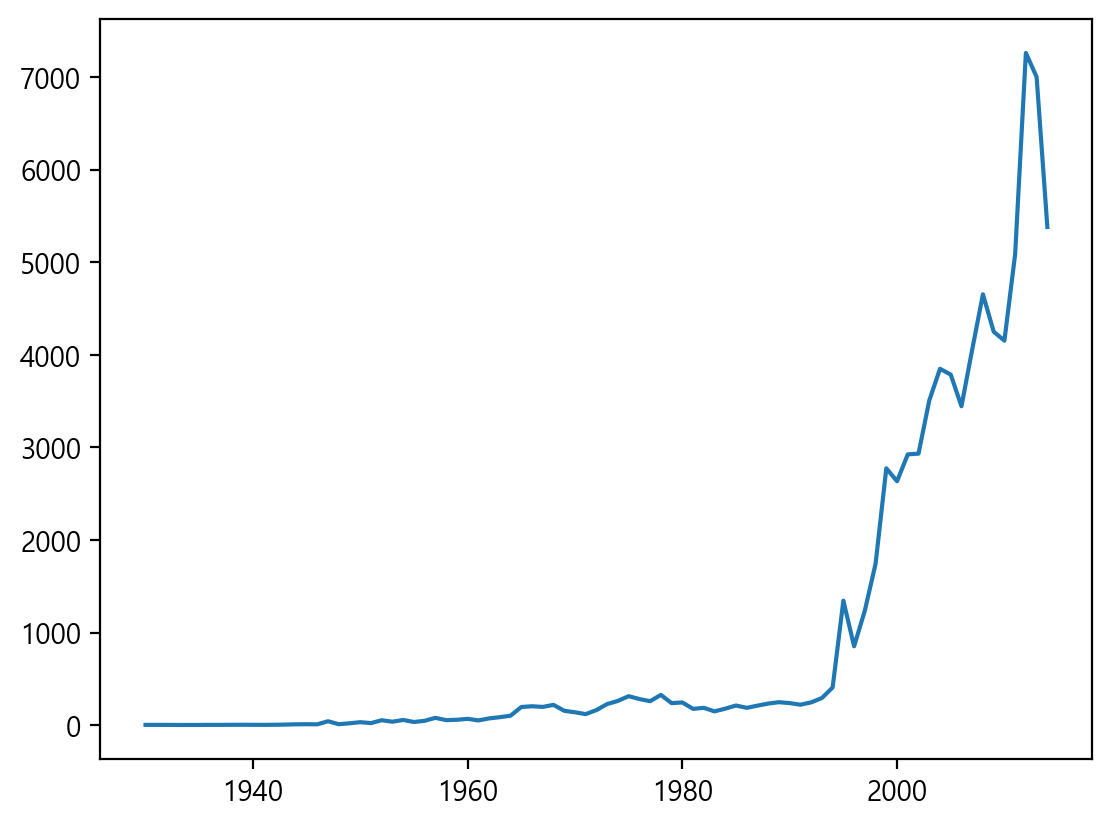

In [37]:
# compare with line plot
ufo.Year.value_counts().sort_index().plot()

## 6. Saving a plot and Changing a style

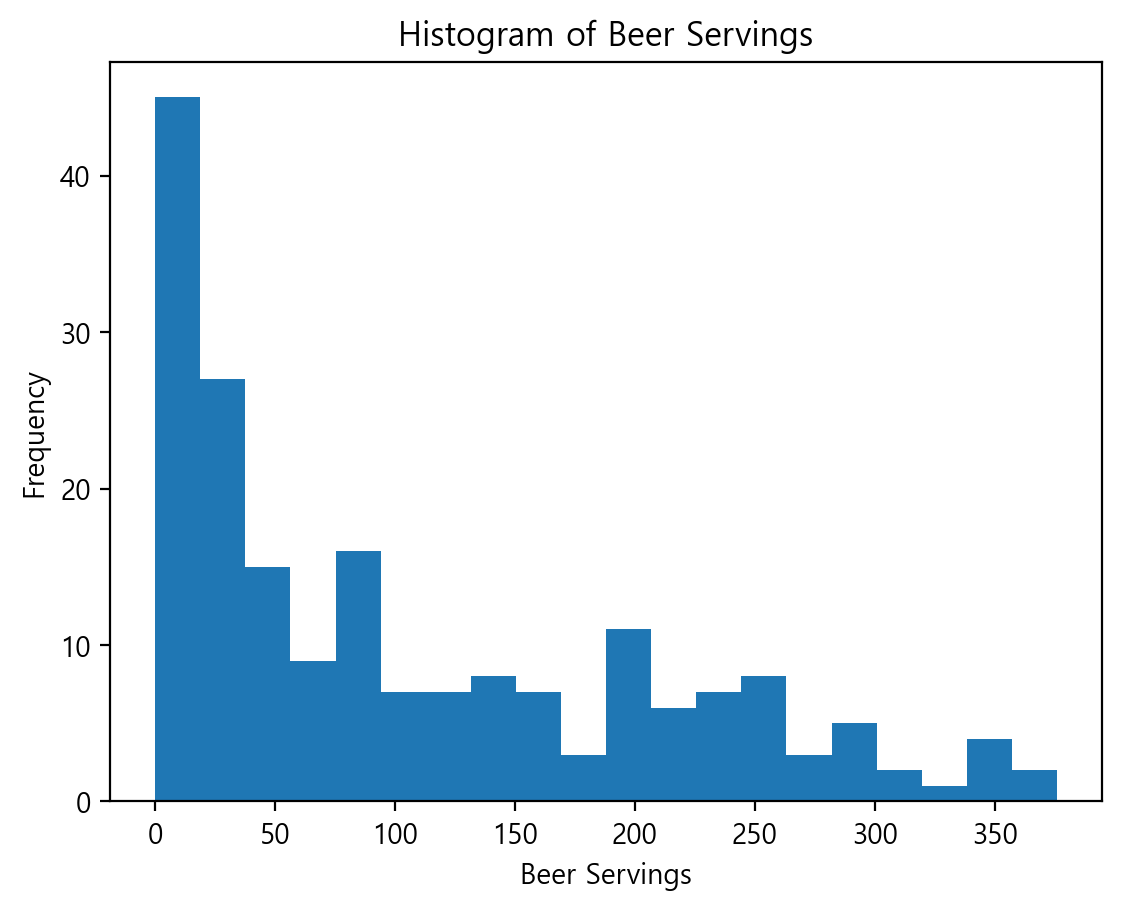

In [38]:
# saving a plot to a file
drinks.beer.plot(kind='hist', bins=20, title='Histogram of Beer Servings')
plt.xlabel('Beer Servings')
plt.ylabel('Frequency')
plt.savefig('image/beer_histogram_original.png')

In [52]:
# list available plot styles
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [39]:
# change to a different style
plt.style.use('ggplot')

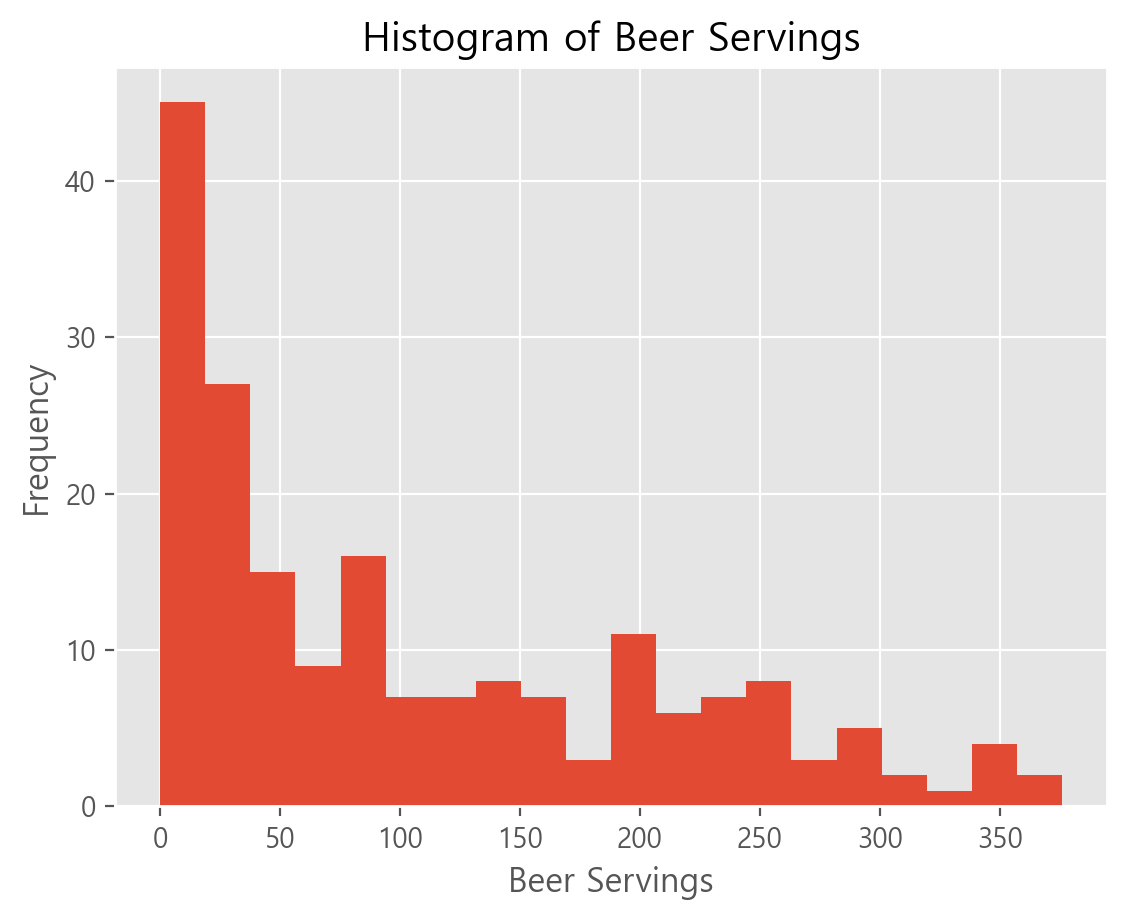

In [40]:
# saving a plot to a file
drinks.beer.plot(kind='hist', bins=20, title='Histogram of Beer Servings')
plt.xlabel('Beer Servings')
plt.ylabel('Frequency')
plt.savefig('image/beer_histogram_ggplot.png')

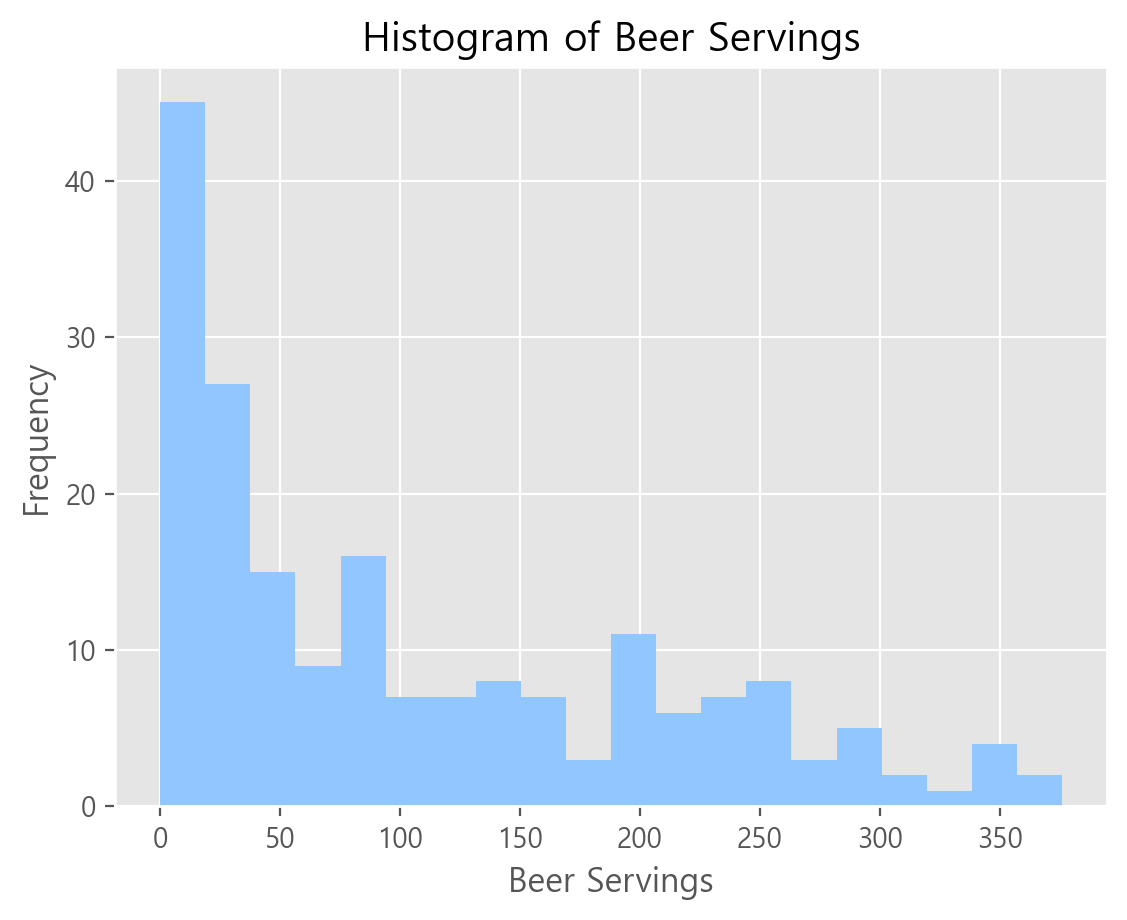

In [41]:
# Other example
plt.style.use('seaborn-pastel')
drinks.beer.plot(kind='hist', bins=20, title='Histogram of Beer Servings')
plt.xlabel('Beer Servings')
plt.ylabel('Frequency')
plt.savefig('image/beer_histogram_seaborn.png')

# 7. Style


**Marker**:
- http://matplotlib.org/1.5.1/examples/lines_bars_and_markers/marker_reference.html
- http://matplotlib.org/api/markers_api.html

**Line**:
- http://matplotlib.org/1.5.1/examples/lines_bars_and_markers/line_styles_reference.html
- http://matplotlib.org/api/lines_api.html

**Color**:
- http://matplotlib.org/examples/color/named_colors.html
- http://matplotlib.org/api/colors_api.html


In [42]:
from IPython.display import Image

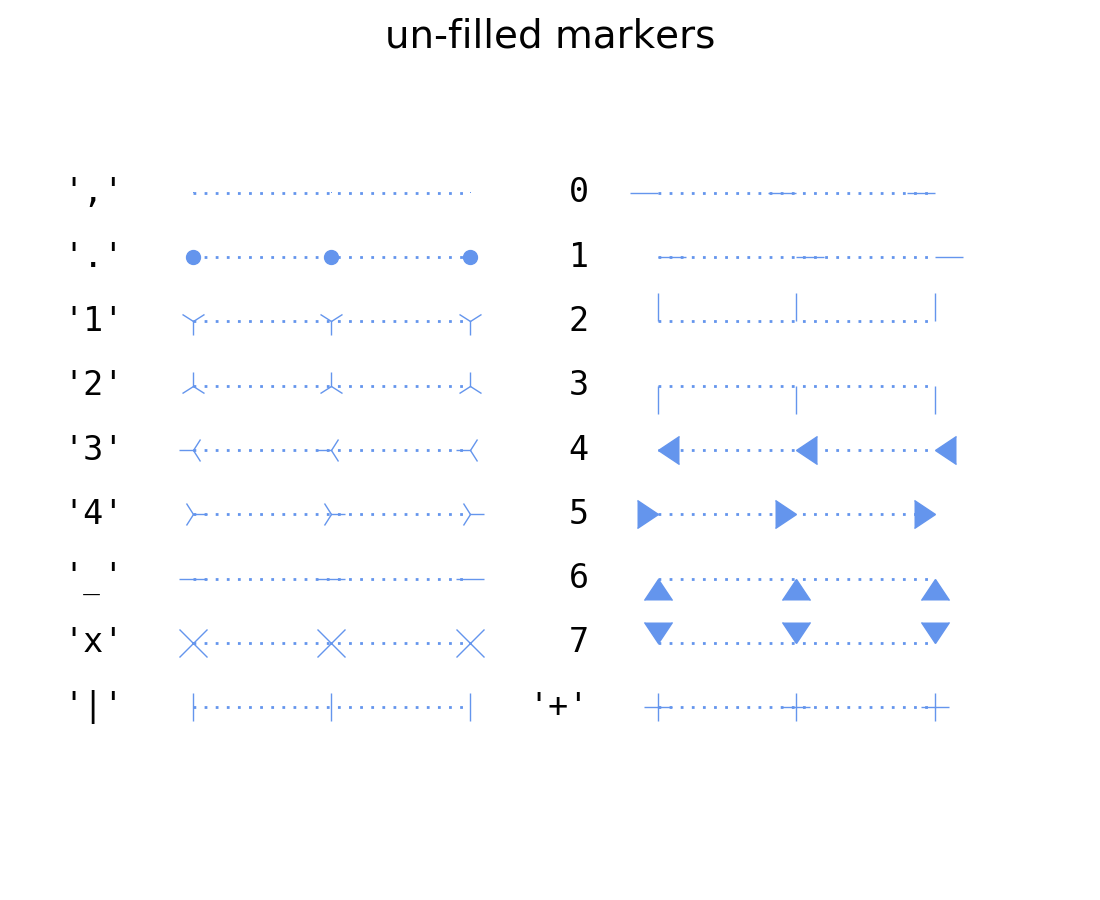

In [43]:
Image(filename="image/marker_reference_00.png")

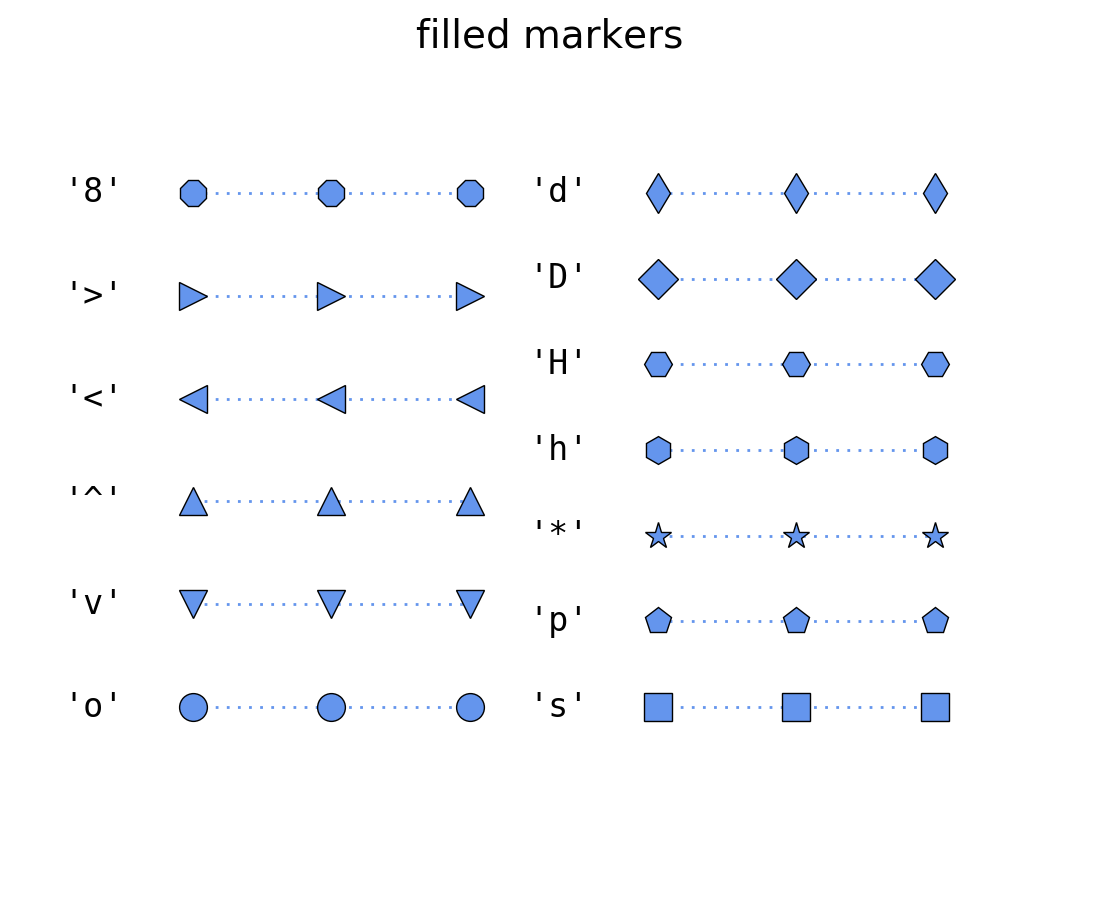

In [59]:
Image(filename="image/marker_reference_01.png")

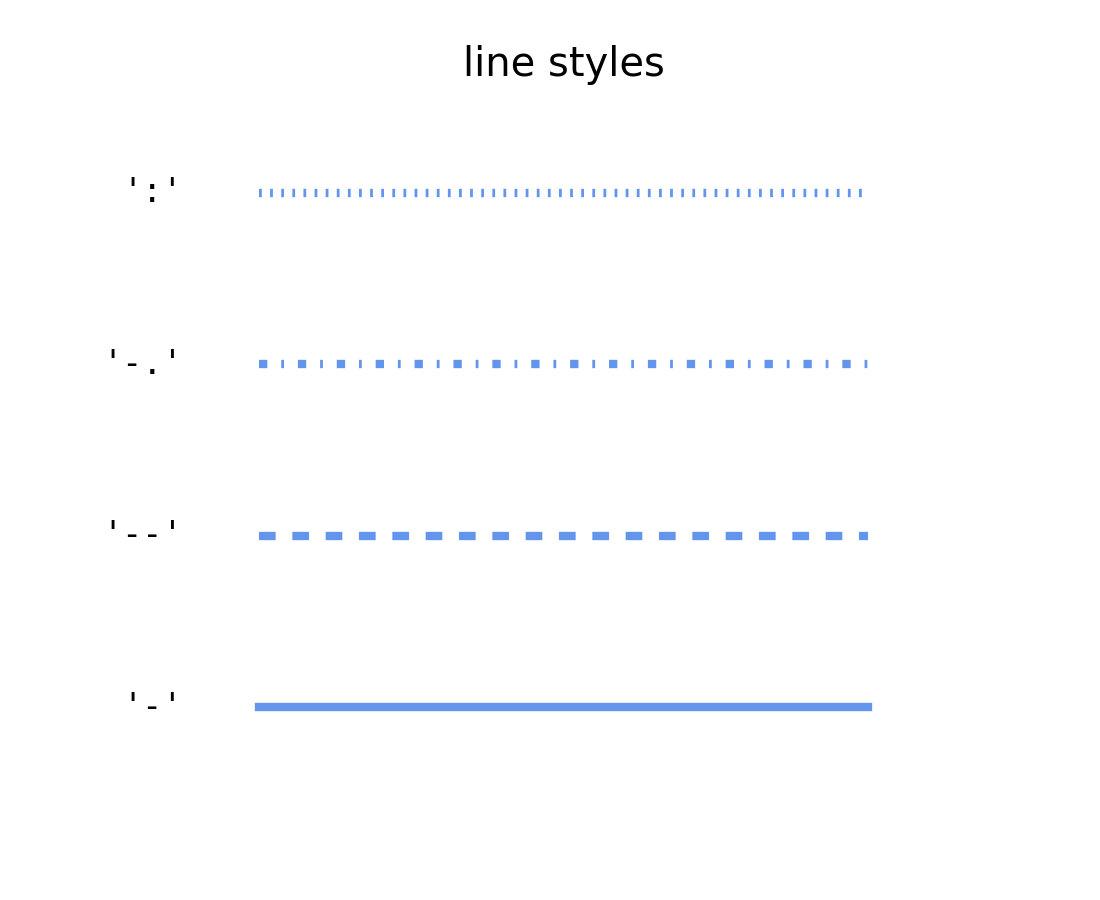

In [60]:
Image(filename="image/line_styles_reference.png")

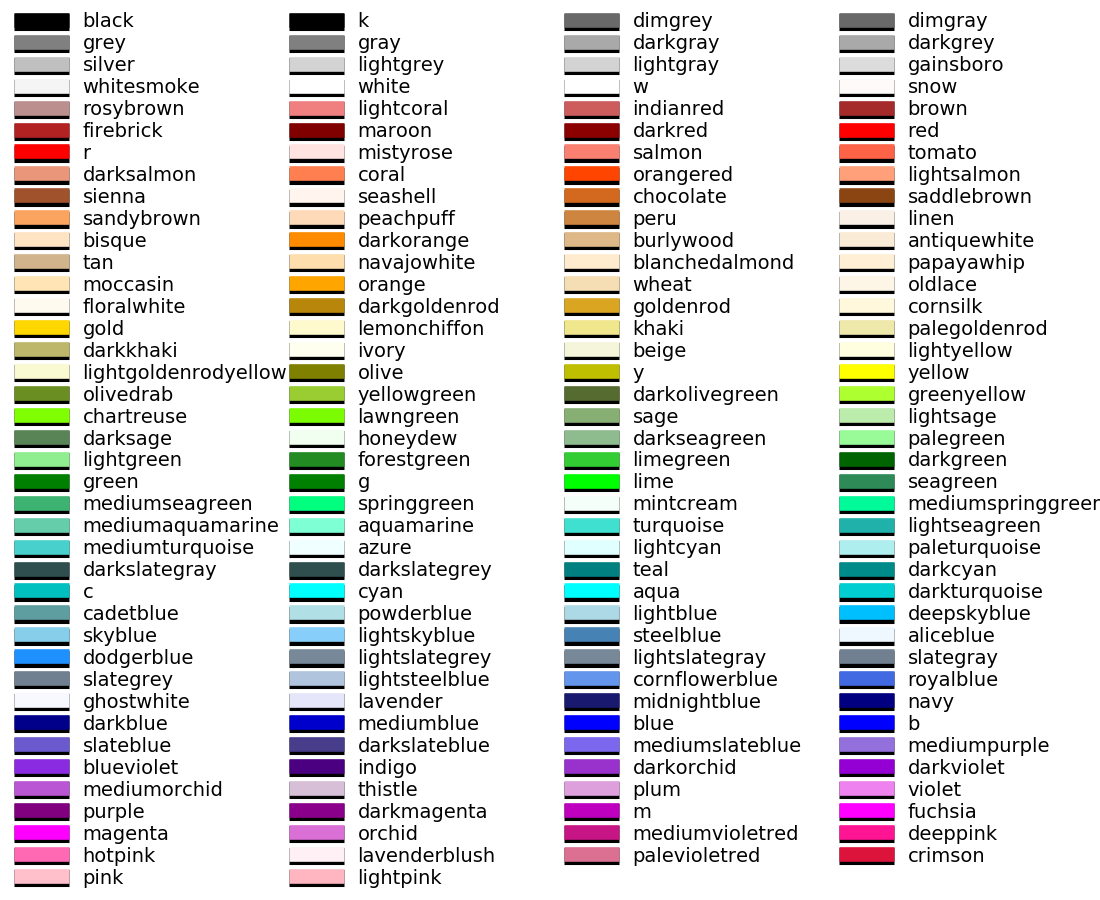

In [61]:
Image(filename="image/named_colors.png")

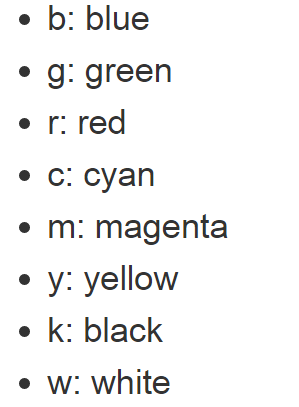

In [62]:
Image(filename="image/named_colors_brief.png")